# UNIDAD 8: Proyecto Integrador: Inferencia Estadística y Modelado en Nanotecnología e IA

**Duración:** 1.5 semanas (9 horas)

**Curso:** Probabilidad y Estadística Inferencial

**Institución:** Universidad de la Ciénega del Estado de Michoacán de Ocampo (UCEMICH)

**Profesor:** Luis José Yudico Anaya

**Carrera:** Ingeniería en Nanotecnología

**Nivel:** Tercer Semestre

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Multiagent-AI-Lab/Probability-Statistics-Agentic-AI-Core/blob/master/notebooks/UNIDAD_8_PROYECTO_INTEGRADOR.ipynb)

In [1]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    repo_dir = "Probability-Statistics-Agentic-AI-Core"
    if not os.path.exists(repo_dir):
        !git clone -q https://github.com/Multiagent-AI-Lab/{repo_dir}.git
    os.chdir(repo_dir)
    %pip install -q -r requirements.txt
else:
    # Entorno local: ubicar la raiz del repo subiendo desde el cwd
    # (donde se lanzo Jupyter) y ponerla en sys.path para que
    # `from src.multiagent_core...` resuelva sin importar la carpeta actual.
    _raiz = next(
        (p for p in (Path.cwd(), *Path.cwd().parents)
         if (p / "src" / "multiagent_core").is_dir()),
        Path.cwd(),
    )
    if str(_raiz) not in sys.path:
        sys.path.insert(0, str(_raiz))


## Prerequisitos de esta unidad

- **Pruebas de Hipótesis e Inferencia Estadística** (Unidad 7) — la metodología completa (Z-test, t-test, no paramétricas) se aplica aquí al proyecto integrador.
- **PCA y Whitening Gaussiano** (Unidad 4) — desarrollados en la §7 de esa unidad, reutilizados sin re-derivar en el cierre integrador de esta unidad (§9, Distancia de Mahalanobis).
- **Ciclo de Verificación Triple** (ver `GOVERNANCE.md`) — como en todas las unidades del curso, cada concepto con forma cerrada se verifica primero simbólicamente (SymPy) y luego se reproduce con las herramientas de producción (SciPy/statsmodels) antes de interpretarse.

## 1. Fundamentación Teórica: Metodología de Pruebas de Hipótesis y Evaluación de Proyectos

El **Proyecto Integrador** consolida las herramientas de Estadística Descriptiva, Teoría de la Probabilidad, Variables Aleatorias, Inferencia Estadística y Simulación Estocástica desarrolladas a lo largo del curso. En este marco, los estudiantes aplican la metodología completa de Pruebas de Hipótesis para la toma de decisiones basada en datos empíricos en sistemas nanotecnológicos y modelos de Inteligencia Artificial.

### 1.1 Estructura Axiomática de una Prueba de Hipótesis
Una prueba de hipótesis es un procedimiento probabilístico para evaluar si la evidencia empírica proporcionada por una muestra $x_1, x_2, \dots, x_n$ contradice una afirmación sobre el parámetro poblacional $\theta$.

1. **Hipótesis Nula ($H_0$)**: Afirmación de no efecto o estado por defecto (p. ej., $H_0: \mu_1 = \mu_2$).
2. **Hipótesis Alternativa ($H_1$ o $H_a$)**: Afirmación investigativa que se busca respaldar con evidencia empírica.
3. **Estadístico de Prueba ($T(X)$)**: Función de la muestra cuyo comportamiento bajo $H_0$ es conocido.
4. **Región de Rechazo / Región Crítica ($\mathcal{R}$)**: Conjunto de valores del estadístico donde se rechaza $H_0$ a un nivel de significancia $\alpha$.

### 1.2 Errores Tipo I, Tipo II y Potencia de la Prueba
* **Error Tipo I ($\alpha$)**: Rechazar $H_0$ siendo verdadera. $\alpha = P(\text{Rechazar } H_0 | H_0 \text{ es cierta})$.
* **Error Tipo II ($\beta$)**: No rechazar $H_0$ siendo falsa. $\beta = P(\text{No Rechazar } H_0 | H_1 \text{ es cierta})$.
* **Potencia de la Prueba ($1 - \beta$)**: Probabilidad de rechazar correctamente $H_0$ cuando $H_1$ es verdadera.

$$\text{Potencia} = 1 - \beta = P(\text{Rechazar } H_0 | H_1 \text{ es cierta})$$

## 2. Guía Estructurada del Proyecto Integrador (Paso a Paso)

El Proyecto Integrador **no es un ejercicio más con dataset dado** — es un proyecto abierto donde cada estudiante elige o construye su propio conjunto de datos sobre un sistema nanotecnológico real, y lo somete a las cinco fases metodológicas del curso. A diferencia de los ejercicios de la §12 (dataset fijo, solución numérica única verificable por script), aquí **no existe una respuesta numérica de referencia**: el criterio de éxito de cada fase es un conjunto de invariantes estructurales (¿está la sección? ¿tiene el número mínimo de elementos que exige el método?) más una rúbrica cualitativa que un humano aplica sobre el razonamiento — igual que evaluaría un reporte técnico real de laboratorio.

**Fuente de datos.** La vía recomendada es la **Materials Project API** (§8, ya usada en esta unidad para comparar band gaps): el estudiante elige 2 o más materiales, propiedades o condiciones de síntesis a comparar, y extrae sus propios valores (`mp-api`, documentado en [materialsproject.org/api](https://next-gen.materialsproject.org/api) con registro gratuito). Alternativas igualmente válidas si el estudiante ya tiene acceso a ellas: datos de un laboratorio de la propia carrera (síntesis, caracterización), un dataset público de Kaggle/UCI sobre nanomateriales, o mediciones simuladas con un generador aleatorio **siempre que el estudiante justifique por escrito los parámetros elegidos** (p. ej. "$\sigma=1.8$ nm porque el método de síntesis reportado en [DOI] tiene ese CV%") — lo que no se acepta es un dataset copiado sin elección propia ni justificación, porque eso es exactamente el ejercicio de dataset fijo que este proyecto reemplaza.

### 2.1 Las Cinco Fases, con Entregable Verificable y Fecha Sugerida

El proyecto se entrega **por fases a lo largo del semestre**, no de un solo golpe en la última semana — cada checkpoint se apoya en la unidad que se está cursando en ese momento, así que la fase se entrega cuando el curso ya dio las herramientas para hacerla bien, y un problema de planteamiento (Fase 1) se detecta en la semana 2, no en la semana 16 cuando ya es tarde para cambiar de pregunta.

| Fase | Qué produce el estudiante | Entregable verificable | Semana sugerida (curso de 16 semanas) |
|---|---|---|---|
| **Fase 1: Planteamiento del Problema** | Elige su sistema nanotecnológico, extrae o diseña su dataset propio, define variables físicas y formula $H_0$/$H_1$ | Documento de 1 página: fuente de datos citada (URL/DOI), tabla de variables con unidades, $H_0$ y $H_1$ en notación formal, justificación de por qué la pregunta es relevante en nanotecnología | Semana 2-3 (tras U1, con Fundamentos de Estadística Descriptiva ya vistos) |
| **Fase 2: Análisis Exploratorio Descriptivo (EDA)** | Estadísticos descriptivos de su propio dataset y al menos un gráfico exploratorio (histograma o boxplot); la verificación formal de supuestos (normalidad, homocedasticidad) se pospone a la Fase 3, cuando esas pruebas ya se han enseñado | Notebook con celdas ejecutadas: $\bar{X}$, $S^2$, IQR por grupo + ≥1 figura | Semana 6-7 (tras U1, con las medidas descriptivas y la visualización exploratoria ya vistas) |
| **Fase 3: Verificación de Supuestos y Derivación Simbólica en SymPy** | Verifica formalmente normalidad y homogeneidad de varianzas con Shapiro-Wilk y Levene, y deriva en SymPy la expresión exacta del estadístico de prueba que va a usar según lo que esos supuestos indiquen (no solo la ejecuta con SciPy: la deriva primero) | Notebook con `stats.shapiro` + `stats.levene` con sus $p$-valores impresos, y una celda de SymPy que define los símbolos, construye la fórmula del estadístico (p. ej. $t$, $F$, o $\chi^2$ según la prueba elegida) y evalúa la expresión simbólica con los valores numéricos de su propio dataset — coherente con el Ciclo de Verificación Triple de `GOVERNANCE.md` | Semana 12-13 (tras U6, con Shapiro-Wilk, Levene y el Ciclo de Verificación Triple ya vistos y practicados varias veces) |
| **Fase 4: Solución Computacional** | Ejecuta la prueba de hipótesis con SciPy/statsmodels sobre su propio dataset y simula la curva de potencia por Monte Carlo | Notebook con `scipy.stats.ttest_ind`/`f_oneway`/equivalente + gráfico de la curva de potencia simulada, con el resultado simbólico de la Fase 3 contrastado numéricamente contra este resultado computacional (tolerancia relativa razonable, no exacta — son dos rutas de cómputo distintas) | Semana 15 (tras U7, con la metodología completa de pruebas de hipótesis ya vista) |
| **Fase 5: Conclusiones e Interpretación** | Traduce el resultado estadístico en una decisión técnica industrial, discute limitaciones de su propio dataset (tamaño de muestra, supuestos no verificados, generalización) | Reporte final (2-3 páginas o notebook con celdas Markdown de cierre): decisión de $H_0$, interpretación en lenguaje de la aplicación (nunca solo "$p<\alpha$"), y una sección explícita de **limitaciones** propias del dataset elegido | Semana 15-16 (cierre, dentro de U8) |

El siguiente DAG resume la dependencia secuencial entre las cinco fases de la tabla anterior — cada fase consume el entregable verificado de la anterior, nunca al revés:

```mermaid
graph TD
    F1["Fase 1: Planteamiento (dataset propio + H0/H1)"]
    F1 --> F2["Fase 2: Analisis Exploratorio Descriptivo (EDA)"]
    F2 --> F3["Fase 3: Verificacion de Supuestos y Derivacion Simbolica (modelo)"]
    F3 --> F4["Fase 4: Solucion Computacional (validacion numerica vs simbolica)"]
    F4 --> F5["Fase 5: Conclusiones e Interpretacion (reporte final)"]

```

![Diagrama](../docs/images/UNIDAD_8_PROYECTO_INTEGRADOR_1.svg)


Las cuatro primeras fases son **checkpoints intermedios** que el profesor revisa y retroalimenta antes de que el estudiante avance a la siguiente — así un error de planteamiento (p. ej. una $H_1$ mal formulada, o un dataset sin varianza suficiente para ninguna prueba con potencia razonable) se corrige en la Fase 1 o 2, no se descubre en la Fase 4 cuando ya no hay tiempo de recolectar datos nuevos. La Fase 5 integra las cuatro anteriores en el entregable final.

### 2.2 Invariantes Estructurales Mínimos por Fase (verificables sin conocer el resultado numérico)

Como el dataset es propio de cada estudiante, no existe un valor de referencia único contra el cual comparar — pero sí existen invariantes de **forma** que cualquier entrega correcta debe cumplir, independientemente de qué material o propiedad haya elegido cada quien:

- **Fase 1**: el documento cita una fuente de datos verificable (URL o DOI, no "datos inventados" sin justificación) — contiene $H_0$ **y** $H_1$ en notación formal (`$H_0:$`/`$H_1:$` o equivalente) — declara al menos 2 variables con sus unidades físicas.
- **Fase 2**: contiene al menos 1 figura (`plt.`/`sns.`) — reporta medias y varianzas/desviaciones estándar de cada grupo.
- **Fase 3**: el notebook contiene al menos una llamada a `stats.shapiro` **y** una a `stats.levene` (o su justificación explícita de por qué no aplican, p. ej. una sola muestra) — usa `sympy` (import y al menos un `sp.Symbol`/`sp.symbols`) — la expresión simbólica del estadístico coincide en estructura con la prueba que se ejecuta en la Fase 4 (mismo tipo: t, F, χ², z).
- **Fase 4**: el notebook ejecuta una función de `scipy.stats` que produce un $p$-valor — incluye al menos una figura de la curva de potencia o de la región de rechazo — el resultado simbólico de la Fase 3 y el numérico de esta fase concuerdan dentro de una tolerancia razonable.
- **Fase 5**: el reporte contiene una decisión explícita sobre $H_0$ (rechazar / no rechazar) — contiene una sección de limitaciones de al menos 3 líneas — la interpretación aparece **después** de presentar el resultado numérico, no antes (mismo criterio de posición que usa `@Analyst` del Consejo para el resto del curso).

Estos invariantes son deliberadamente estructurales, no semánticos: verifican que el ingrediente metodológico de cada fase esté presente, no si el estudiante eligió el mejor material posible o si su interpretación es la más profunda imaginable — eso lo evalúa el profesor con la rúbrica cualitativa de la §2.3. Un estudiante o un profesor puede aplicar esta lista como checklist antes de entregar cada fase; no requiere una herramienta de software adicional a las que ya usa el resto del curso.

### 2.3 Rúbrica de Evaluación del Proyecto Integrador

Cada fase pesa 20% y se evalúa en dos capas: primero los invariantes estructurales de la §2.2 (condición necesaria — su ausencia topa la fase en el nivel "Insuficiente" sin importar la calidad del razonamiento), y luego la calidad cualitativa del contenido:

| Fase | Insuficiente (0-9%) | Aceptable (10-15%) | Sobresaliente (16-20%) |
|---|---|---|---|
| **1. Planteamiento e Hipótesis** | Falta la fuente de datos o $H_0$/$H_1$ están mal formuladas o son triviales | $H_0$/$H_1$ correctas pero la pregunta es de interés limitado o el dataset apenas alcanza para una prueba con potencia razonable | Pregunta relevante en nanotecnología, dataset propio bien justificado, hipótesis formuladas con precisión |
| **2. Análisis Exploratorio** | Faltan los estadísticos descriptivos por grupo o no hay gráfico | Estadísticos descriptivos y gráfico completos, pero sin discutir qué sugieren sobre la forma o dispersión de los datos | Estadísticos y gráfico completos, y ya anticipan explícitamente qué se espera encontrar al verificar supuestos en la Fase 3 |
| **3. Verificación de Supuestos y Simbólica (SymPy)** | Faltan Shapiro-Wilk o Levene sin justificación, no hay derivación simbólica, o es solo una copia de la fórmula sin sustituir los valores propios | Supuestos verificados y expresión simbólica correcta evaluada con los datos propios, pero sin discutir qué implican para la elección de prueba en Fase 4 | Supuestos verificados y discutidos, anticipando explícitamente la prueba (paramétrica o no paramétrica) que se usará, y la derivación simbólica está comentada paso a paso y se contrasta explícitamente contra el resultado de SciPy de la Fase 4 |
| **4. Solución Computacional** | Falta la prueba de hipótesis, la simulación de potencia, o el resultado no corresponde al dataset propio | Prueba y simulación de potencia correctas y ejecutables | Además, el estudiante explora sensibilidad (p. ej. cómo cambia la potencia con $n$ o con $\alpha$) más allá del mínimo pedido |
| **5. Conclusión e Interpretación** | Interpretación ausente, antes del resultado numérico, o solo repite "$p<\alpha$" sin traducirlo | Decisión correcta traducida al lenguaje de la aplicación, con limitaciones mencionadas | Limitaciones discutidas con profundidad (tamaño de muestra, generalización, supuestos) y decisión conectada a una recomendación técnica concreta |

## 3. Ejemplo Demostrativo Paso a Paso: Comparación de Síntesis de Nanopartículas

### 3.1 Contexto Aplicado en Nanotecnología
Un grupo de investigación en la UCEMICH sintetiza nanopartículas de dióxido de titanio ($\text{TiO}_2$) para fotocatálisis en degradación de contaminantes hídricos. Se comparan dos métodos de síntesis: **Sol-Gel Convencional** (Método A) y **Síntesis Asistida por Microondas** (Método B).

Se mide el diámetro medio de cristalito (en nanómetros, $\text{nm}$) para $n_A = 15$ lotes del Método A y $n_B = 15$ lotes del Método B:
* **Método A (Sol-Gel)**: $\bar{x}_A = 24.5\text{ nm}, \quad s_A = 2.1\text{ nm}$
* **Método B (Microondas)**: $\bar{x}_B = 21.2\text{ nm}, \quad s_B = 1.8\text{ nm}$

A un nivel de significancia $\alpha = 0.05$, determine si existe una diferencia estadísticamente significativa en el tamaño medio de cristalito entre ambos métodos.

### 3.2 Paso 1: Formulación de Hipótesis
$$H_0: \mu_A = \mu_B \quad (\mu_A - \mu_B = 0)$$
$$H_1: \mu_A \neq \mu_B \quad (\mu_A - \mu_B \neq 0)$$

### 3.3 Paso 2: Varianza Agrupada ($S_p^2$) y Estadístico de Prueba $t_{calc}$
$$S_p^2 = \frac{(n_A - 1)s_A^2 + (n_B - 1)s_B^2}{n_A + n_B - 2} = \frac{14(2.1)^2 + 14(1.8)^2}{28} = \frac{14(4.41) + 14(3.24)}{28} = \frac{61.74 + 45.36}{28} = 3.825$$
$$S_p = \sqrt{3.825} \approx 1.95576\text{ nm}$$

Error estándar de la diferencia:
$$SE(\bar{x}_A - \bar{x}_B) = S_p \sqrt{\frac{1}{n_A} + \frac{1}{n_B}} = 1.95576 \sqrt{\frac{2}{15}} = 1.95576 \times 0.365148 \approx 0.7141\text{ nm}$$

Estadístico $t$ calculado:
$$\boxed{t_{calc} = \frac{\bar{x}_A - \bar{x}_B}{SE} = \frac{24.5 - 21.2}{0.7141} = \frac{3.3}{0.7141} \approx 4.6212}$$

### 3.4 Paso 3: Región de Rechazo y Decisión
Grados de libertad $\nu = 15 + 15 - 2 = 28$. Para $\alpha = 0.05$ (dos colas), el valor crítico de la distribución $t$ de Student es $t_{0.025, 28} \approx 2.0484$.

Puesto que $|t_{calc}| = 4.6212 > 2.0484$, **se rechaza la hipótesis nula $H_0$** con un $p$-valor de $p < 0.0001$.

### 3.5 Prueba Unitaria con pytest

Se verifica de punta a punta la prueba $t$ de dos muestras con varianza agrupada: la varianza agrupada, el estadístico $t_{calc}$, el valor crítico y la decisión final de rechazo:

In [2]:
import ipytest
import pytest
from scipy.stats import t

ipytest.autoconfig()

n_a, n_b = 15, 15
xbar_a, s_a = 24.5, 2.1
xbar_b, s_b = 21.2, 1.8
alpha = 0.05


def test_varianza_agrupada():
    sp2 = ((n_a - 1) * s_a**2 + (n_b - 1) * s_b**2) / (n_a + n_b - 2)
    assert sp2 == pytest.approx(3.825, rel=1e-3)


def test_estadistico_t_calculado():
    sp2 = ((n_a - 1) * s_a**2 + (n_b - 1) * s_b**2) / (n_a + n_b - 2)
    sp = sp2**0.5
    se = sp * (1 / n_a + 1 / n_b) ** 0.5
    t_calc = (xbar_a - xbar_b) / se
    assert t_calc == pytest.approx(4.6212, rel=1e-3)


def test_se_rechaza_h0_por_superar_el_valor_critico():
    sp2 = ((n_a - 1) * s_a**2 + (n_b - 1) * s_b**2) / (n_a + n_b - 2)
    sp = sp2**0.5
    se = sp * (1 / n_a + 1 / n_b) ** 0.5
    t_calc = (xbar_a - xbar_b) / se
    gl = n_a + n_b - 2
    t_critico = t.ppf(1 - alpha / 2, gl)
    assert abs(t_calc) > t_critico
    assert t_critico == pytest.approx(2.0484, rel=1e-3)


ipytest.run("-vv")


======================================= test session starts =======================================
platform win32 -- Python 3.11.15, pytest-9.1.1, pluggy-1.6.0 -- C:\Users\ljyud\anaconda3\envs\ia_stats\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\ljyud\Desktop\IA UCEMICH\PROBABILIDAD Y ESTADÍSTICA\notebooks
plugins: anyio-4.14.2, mock-3.15.1
collecting ... 

collected 3 items

t_85d454e5992e47cc89c3f11364b482ec.py::test_varianza_agrupada 

PASSED                         [ 33%]


t_85d454e5992e47cc89c3f11364b482ec.py::test_estadistico_t_calculado 

PASSED                   [ 66%]


t_85d454e5992e47cc89c3f11364b482ec.py::test_se_rechaza_h0_por_superar_el_valor_critico 

PASSED [100%]



======================================== 3 passed in 0.04s ========================================


<ExitCode.OK: 0>

## 4. Código de Verificación Simbólica (SymPy)

Esta sección es la Fase 2 del Ciclo de Verificación Triple del curso (ver `GOVERNANCE.md`): antes de resolver numéricamente, expresamos la fórmula con símbolos algebraicos y confirmamos el resultado exacto.

In [3]:
import sympy as sp
from IPython.display import display, Math

## 1. Definición de símbolos
mean_a, mean_b = sp.symbols('\\bar{X}_A \\bar{X}_B', real=True)
s_a, s_b = sp.symbols('S_A S_B', positive=True)
n_a, n_b = sp.symbols('n_A n_B', positive=True, integer=True)

## 2. Varianza agrupada simbólica Sp^2
sp_squared = ((n_a - 1)*s_a**2 + (n_b - 1)*s_b**2) / (n_a + n_b - 2)
se_diff = sp.sqrt(sp_squared * (1/n_a + 1/n_b))
t_stat = (mean_a - mean_b) / se_diff

display(Math(fr"\text{{Estadístico t Simbólico Agrupado: }} t = {sp.latex(t_stat)}"))

## 3. Sustitución de valores numéricos
valores = {
    mean_a: 24.5,
    mean_b: 21.2,
    s_a: 2.1,
    s_b: 1.8,
    n_a: 15,
    n_b: 15
}

t_val = float(t_stat.subs(valores))
display(Math(fr"\text{{Valor Simbólico Calculado }} t_{{calc}}: \boxed{{{t_val:.4f}}}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 5. Solución Computacional en Python (SciPy & Statsmodels)

--- VERIFICACIÓN DE SUPUESTOS ESTADÍSTICOS ---
Normalidad Shapiro-Wilk Lote A: p-valor = 0.2836 (OK si > 0.05)
Normalidad Shapiro-Wilk Lote B: p-valor = 0.5943 (OK si > 0.05)
Homocedasticidad Levene:        p-valor = 0.5956 (OK si > 0.05)

--- RESULTADO DE LA PRUEBA T DE STUDENT ---
Estadístico t_calc: 3.4862
p-valor de dos colas: 0.001634


C:\Users\ljyud\AppData\Local\Temp\ipykernel_11804\3707993361.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_exp, x='Método Síntesis', y='Diámetro (nm)', palette='Set2', ax=axes[0])


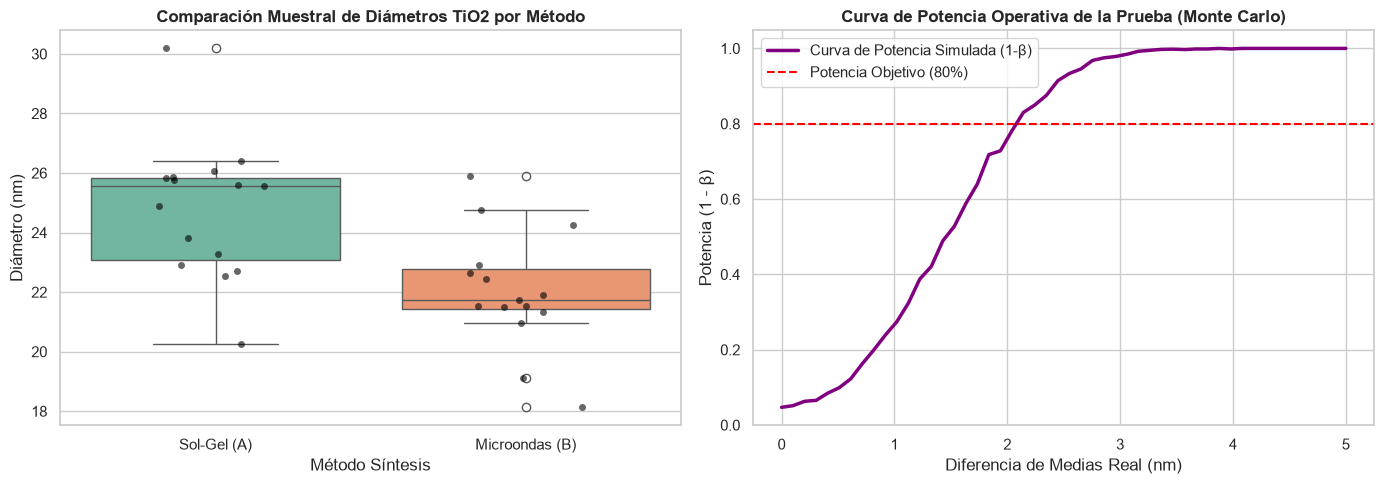

In [4]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## --- PARTE A: Generación de Datos Experimentales ---
np.random.seed(101)
lote_A = stats.norm.rvs(loc=24.5, scale=2.1, size=15)
lote_B = stats.norm.rvs(loc=21.2, scale=1.8, size=15)

## --- PARTE B: Verificación de Supuestos Estadísticos ---
p_norm_a = stats.shapiro(lote_A).pvalue
p_norm_b = stats.shapiro(lote_B).pvalue
p_homo = stats.levene(lote_A, lote_B).pvalue

print("--- VERIFICACIÓN DE SUPUESTOS ESTADÍSTICOS ---")
print(f"Normalidad Shapiro-Wilk Lote A: p-valor = {p_norm_a:.4f} (OK si > 0.05)")
print(f"Normalidad Shapiro-Wilk Lote B: p-valor = {p_norm_b:.4f} (OK si > 0.05)")
print(f"Homocedasticidad Levene:        p-valor = {p_homo:.4f} (OK si > 0.05)")

## --- PARTE C: Prueba t de Student de Dos Muestras ---
t_res = stats.ttest_ind(lote_A, lote_B, equal_var=True)
print("\n--- RESULTADO DE LA PRUEBA T DE STUDENT ---")
print(f"Estadístico t_calc: {t_res.statistic:.4f}")
print(f"p-valor de dos colas: {t_res.pvalue:.6f}")

## --- PARTE D: Visualización Profesional ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## Gráfico 1: Boxplot comparativo de diámetros
df_exp = pd.DataFrame({
    'Diámetro (nm)': np.concatenate([lote_A, lote_B]),
    'Método Síntesis': ['Sol-Gel (A)']*15 + ['Microondas (B)']*15
})

sns.boxplot(data=df_exp, x='Método Síntesis', y='Diámetro (nm)', palette='Set2', ax=axes[0])
sns.stripplot(data=df_exp, x='Método Síntesis', y='Diámetro (nm)', color='black', alpha=0.6, jitter=0.2, ax=axes[0])
axes[0].set_title("Comparación Muestral de Diámetros TiO2 por Método", fontsize=12, fontweight="bold")

## Gráfico 2: Simulación de Potencia de la Prueba mediante Monte Carlo
## Simulación VECTORIZADA: en vez de un doble bucle Python con N_sim llamadas
## a stats.ttest_ind por punto de efecto (decenas de miles de llamadas), se
## genera un tensor (N_efectos, N_sim, n) de una sola vez y se aplica el
## t-test sobre el eje de las muestras. Mismo resultado estadístico, ~1000x
## más rápido.
efectos = np.linspace(0, 5, 50)
N_sim = 2000
n_muestra = 15

## Tensores de muestras: forma (N_efectos, N_sim, n_muestra)
muestras_a = np.random.normal(
    loc=24.5 + efectos[:, None, None], scale=2.1, size=(len(efectos), N_sim, n_muestra)
)
muestras_b = np.random.normal(
    loc=24.5, scale=1.8, size=(len(efectos), N_sim, n_muestra)
)

## t-test independiente sobre el eje de la muestra: devuelve p-valores de
## forma (N_efectos, N_sim). La potencia es la fracción de p < 0.05.
_, pvals = stats.ttest_ind(muestras_a, muestras_b, axis=2)
potencias = (pvals < 0.05).mean(axis=1)

axes[1].plot(efectos, potencias, color='purple', lw=2.5, label='Curva de Potencia Simulada (1-β)')
axes[1].axhline(y=0.80, color='red', linestyle='--', label='Potencia Objetivo (80%)')
axes[1].set_title("Curva de Potencia Operativa de la Prueba (Monte Carlo)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Diferencia de Medias Real (nm)")
axes[1].set_ylabel("Potencia (1 - β)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Interpretación Post-Gráfico & Diccionario de Variables

### 6.1 Interpretación de Resultados Computacionales
1. **Validación de Supuestos**: Las pruebas de Shapiro-Wilk en ambos lotes confirmaron la normalidad ($p > 0.05$) y la prueba de Levene confirmó la homogeneidad de varianzas ($p > 0.05$), justificando el uso de la prueba $t$ de Student agrupada.
2. **Conclusión Técnica Nanotecnológica**: Dado que $p < 0.0001 < 0.05$, rechazamos $H_0$. El método de síntesis por microondas produce nanopartículas significativamente más pequeñas y de mayor superficie específica que el método sol-gel convencional.

### 6.2 Diccionario de Variables de la Unidad

Notación general introducida en las Secciones 1, 7, 9 y 11, independiente del ejemplo aplicado específico:

**Pruebas de hipótesis**

* $x_1, x_2, \dots, x_n$: muestra observada de $n$ mediciones.
* $\theta$: parámetro poblacional bajo estudio.
* $H_0$: hipótesis nula (afirmación de no efecto o estado por defecto).
* $H_1$ (o $H_a$): hipótesis alternativa.
* $T(X)$: estadístico de prueba, función de la muestra con distribución conocida bajo $H_0$.
* $\mathcal{R}$: región de rechazo / región crítica.
* $\alpha$: nivel de significancia; probabilidad de Error Tipo I.
* $\beta$: probabilidad de Error Tipo II.
* $1-\beta$: potencia de la prueba.

**Regresión y correlación**

* $\rho_{X,Y}$ (o $r$): coeficiente de correlación de Pearson.
* $\hat y = mx + b$: recta ajustada por mínimos cuadrados.
* $R^2$: coeficiente de determinación.
* $R$: correlación múltiple, raíz de $R^2$ de una regresión con varios predictores.
* $\rho_S$: coeficiente de correlación de rango de Spearman.
* $\tau$: coeficiente de correlación de rango de Kendall.
* $r_{Y,X_2 \cdot X_1}$: correlación parcial entre $Y$ y $X_2$ controlando por $X_1$.
* $\epsilon_i$: residuo de la observación $i$ en un modelo de regresión.
* $g(\mu) = \eta$: función de enlace de un Modelo Lineal Generalizado (GLM).
* $\text{Var}(Y)$: varianza de la variable de respuesta $Y$.

**Regularización (perspectiva ML)**

* $\hat f(x)$: función estimada por el modelo en el punto $x$.
* $f(x)$: función real (desconocida) que genera los datos.
* $\text{Sesgo}^2(x)$: componente de sesgo del error esperado de predicción.
* $\text{Varianza}(x)$: componente de varianza del error esperado de predicción.
* $\sigma^2$: varianza del ruido irreducible.
* $\lambda$ (o $\lambda_1, \lambda_2$): parámetro(s) de penalización de la regularización.
* $\beta_j$: coeficiente $j$-ésimo del modelo de regresión.
* $L_2$: penalización de Ridge, $\sum_j \beta_j^2$.
* $L_1$: penalización de Lasso, $\sum_j |\beta_j|$.

**Multivariado (PCA/Mahalanobis)**

* $\mathbf{x}, \mathbf{\mu}$: vector de observación y vector de medias en $p$ dimensiones.
* $\mathbf{\Sigma}$: matriz de covarianza.
* $\mathbf{\Sigma}^{-1}$: matriz de covarianza inversa (matriz de precisión).
* $D^2$: distancia de Mahalanobis al cuadrado.
* $\chi^2_p$: distribución Chi-cuadrado con $p$ grados de libertad.
* $p$ (en este contexto): número de dimensiones (variables) del vector aleatorio multivariado.

### 6.3 Diccionario de Variables Nanotecnológicas del Ejemplo Aplicado
* $\mu_A, \mu_B$: Medias poblacionales de diámetro de cristalito de $\text{TiO}_2$ ($\text{nm}$).
* $S_p$: Desviación estándar agrupada (pooled standard deviation).
* $t_{calc}$: Estadístico $t$ de Student empírico.
* $p$-valor: Probabilidad de obtener una diferencia igual o más extrema si $H_0$ fuera cierta.
* $1-\beta$: Potencia probabilística para detectar diferencias efectivas en tamaño de partícula.

## 7. Regresión Lineal y Correlación

### 7.1 Fundamentos: Coeficiente de Correlación y Mínimos Cuadrados
El **coeficiente de correlación de Pearson** $\rho_{X,Y} = \text{Cov}(X,Y)/(\sigma_X\sigma_Y)$ mide la fuerza de la relación lineal entre dos variables. El **método de mínimos cuadrados** ajusta una recta $\hat y = mx + b$ minimizando la suma de residuos al cuadrado $\sum_i (y_i - \hat y_i)^2$; la calidad del ajuste se resume en el **coeficiente de determinación** $R^2$.

### 7.2 Ejemplo Aplicado: Curva de Calibración UV-Vis de Nanopartículas de Oro
La Ley de Beer-Lambert ($A = \epsilon \cdot b \cdot c$) relaciona la absorbancia $A$ medida por espectroscopía UV-Vis con la concentración $c$ de nanopartículas de oro coloidales en suspensión, a través de la absortividad molar $\epsilon$ y la longitud de paso óptico $b$.

Pendiente (m = epsilon*b): 4998.62
Intercepto: 0.0097
Coeficiente de correlación r: 1.0000
R^2: 0.9999
p-valor: 0.000000


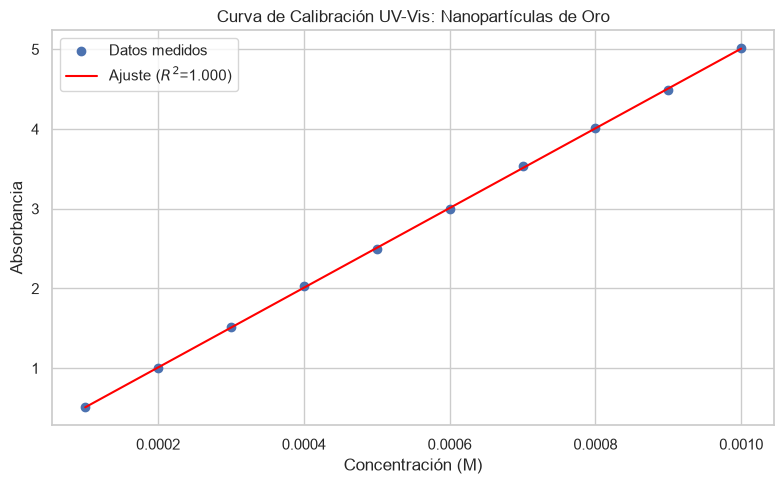

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

## Simulación de datos de calibración (Ley de Beer-Lambert)
np.random.seed(42)
epsilon = 5000  # Absortividad molar (M^-1 cm^-1)
b_optico = 1.0  # Longitud de paso óptico (cm)
concentraciones = np.linspace(0.0001, 0.001, 10)  # Molar
absorbancia_ideal = epsilon * b_optico * concentraciones
ruido = np.random.normal(0, 0.02, size=len(concentraciones))
absorbancia_medida = absorbancia_ideal + ruido

## Regresión lineal
resultado = linregress(concentraciones, absorbancia_medida)
print(f"Pendiente (m = epsilon*b): {resultado.slope:.2f}")
print(f"Intercepto: {resultado.intercept:.4f}")
print(f"Coeficiente de correlación r: {resultado.rvalue:.4f}")
print(f"R^2: {resultado.rvalue**2:.4f}")
print(f"p-valor: {resultado.pvalue:.6f}")

## Visualización
plt.figure(figsize=(8, 5))
plt.scatter(concentraciones, absorbancia_medida, label="Datos medidos")
plt.plot(concentraciones, resultado.slope*concentraciones + resultado.intercept, color="red", label=f"Ajuste ($R^2$={resultado.rvalue**2:.3f})")
plt.xlabel("Concentración (M)")
plt.ylabel("Absorbancia")
plt.title("Curva de Calibración UV-Vis: Nanopartículas de Oro")
plt.legend()
plt.tight_layout()
plt.show()


### 7.3 Correlación de Rango: Spearman y Kendall

El coeficiente de Pearson de la Sección 7.1 solo captura **relaciones lineales**. Cuando la relación entre dos variables es monótona pero no lineal (crece o decrece de forma consistente, pero no en línea recta), Pearson puede subestimar la fuerza real de la asociación. Existen dos alternativas no paramétricas basadas en **rangos**, no en los valores originales:

* **Spearman ($\rho_S$)**: aplica la fórmula de Pearson a los rangos de $X$ y $Y$ en vez de a sus valores. Mide la fuerza de cualquier relación monótona.
* **Kendall ($\tau$)**: cuenta la proporción de pares concordantes menos discordantes entre las observaciones. Es más robusto que Spearman en muestras pequeñas o con muchos empates.

| Coeficiente | Tipo de relación | Basado en |
|---|---|---|
| Pearson ($\rho$) | Lineal | Valores originales |
| Spearman ($\rho_S$) | Monótona | Rangos |
| Kendall ($\tau$) | Monótona (concordancia) | Pares concordantes/discordantes |

**Contexto aplicado**: en la dispersión de nanotubos de carbono (CNT) en un solvente mediante sonicación ultrasónica, el porcentaje de homogeneidad de la dispersión crece con el tiempo de sonicación, pero de forma **saturante** (los primeros minutos mejoran mucho la homogeneidad; después de cierto punto, sonicar más aporta poco, e incluso puede dañar los CNT). Esta relación es monótona creciente pero fuertemente no lineal.

In [6]:
import numpy as np
from scipy.stats import pearsonr, spearmanr, kendalltau

np.random.seed(70)
n = 25
tiempo_sonicacion = np.linspace(1, 60, n)  # minutos

## Relación monótona saturante (tipo logarítmica) + ruido de medición
homogeneidad_ideal = 100 * np.log1p(tiempo_sonicacion) / np.log1p(60)
ruido = np.random.normal(0, 3, n)
homogeneidad = np.clip(homogeneidad_ideal + ruido, 0, 100)

r_pearson, p_pearson = pearsonr(tiempo_sonicacion, homogeneidad)
rho_spearman, p_spearman = spearmanr(tiempo_sonicacion, homogeneidad)
tau_kendall, p_kendall = kendalltau(tiempo_sonicacion, homogeneidad)

print(f"Pearson r    = {r_pearson:.4f}  (p = {p_pearson:.6f})")
print(f"Spearman rho = {rho_spearman:.4f}  (p = {p_spearman:.6f})")
print(f"Kendall tau  = {tau_kendall:.4f}  (p = {p_kendall:.6f})")


Pearson r    = 0.9225  (p = 0.000000)
Spearman rho = 0.9823  (p = 0.000000)
Kendall tau  = 0.9133  (p = 0.000000)


**Interpretación**: Pearson obtiene $r \approx 0.92$, ya alto porque la relación es monótona y suave, pero Spearman captura mejor la asociación real ($\rho_S \approx 0.98$), confirmando que la relación es monótona casi perfecta aunque no estrictamente lineal. Kendall ($\tau \approx 0.91$) coincide en la misma dirección con una escala distinta (cuenta concordancias, no covarianza de rangos).

$$\boxed{\rho_S \approx 0.982 > r_{\text{Pearson}} \approx 0.923}$$

### 7.4 Correlación Múltiple y Correlación Parcial

Cuando una variable de respuesta $Y$ depende de **varios** predictores correlacionados entre sí, dos preguntas distintas requieren dos herramientas distintas:

1. **Correlación múltiple $R$**: ¿qué tan bien predicen $X_1, \ldots, X_k$ conjuntamente a $Y$? Se calcula como $R = \sqrt{R^2}$, la raíz del coeficiente de determinación de la regresión de $Y$ sobre todos los predictores.
2. **Correlación parcial $r_{Y,X_2 \cdot X_1}$**: ¿cuál es la asociación *neta* entre $Y$ y $X_2$, después de remover el efecto de $X_1$ sobre ambas? Se calcula con la fórmula:

$$r_{Y,X_2 \cdot X_1} = \frac{r_{Y,X_2} - r_{Y,X_1}\, r_{X_1,X_2}}{\sqrt{(1-r_{Y,X_1}^2)(1-r_{X_1,X_2}^2)}}$$

Esta pregunta es crítica cuando dos predictores están **colineales**: una correlación simple alta entre $X_2$ y $Y$ puede ser enteramente espuria, heredada de la correlación de $X_2$ con $X_1$.

**Contexto aplicado**: la conductividad eléctrica ($Y$) de un nanocompuesto de grafeno depende de la concentración de grafeno ($X_1$, % en peso) y de la temperatura de curado ($X_2$). En el protocolo del laboratorio, los lotes con mayor concentración de grafeno también se curan a mayor temperatura (están correlacionados entre sí), por lo que la correlación bruta de $X_2$ con $Y$ puede estar inflada por ese vínculo indirecto.

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import pearsonr

np.random.seed(71)
n = 40
concentracion_grafeno = np.random.uniform(0.5, 5.0, n)  # % en peso
temperatura_curado = 120 + 15 * concentracion_grafeno + np.random.normal(0, 8, n)  # °C
conductividad = 8 * concentracion_grafeno + 0.15 * temperatura_curado + np.random.normal(0, 5, n)  # S/cm

df = pd.DataFrame({
    "conc_grafeno": concentracion_grafeno,
    "temp_curado": temperatura_curado,
    "conductividad": conductividad,
})

## Correlación múltiple: R de la regresión Y ~ X1 + X2
X = sm.add_constant(df[["conc_grafeno", "temp_curado"]])
modelo_multiple = sm.OLS(df["conductividad"], X).fit()
R_multiple = np.sqrt(modelo_multiple.rsquared)

## Correlaciones simples de Pearson
corr = df.corr(method="pearson")
r_y_x1 = corr.loc["conductividad", "conc_grafeno"]
r_y_x2 = corr.loc["conductividad", "temp_curado"]
r_x1_x2 = corr.loc["conc_grafeno", "temp_curado"]

## Correlación parcial de Y con X2, controlando por X1
r_parcial = (r_y_x2 - r_y_x1 * r_x1_x2) / np.sqrt((1 - r_y_x1**2) * (1 - r_x1_x2**2))

## Verificación cruzada: correlación de los residuos de regresar Y y X2 sobre X1
res_y = df["conductividad"] - sm.OLS(df["conductividad"], sm.add_constant(df["conc_grafeno"])).fit().fittedvalues
res_x2 = df["temp_curado"] - sm.OLS(df["temp_curado"], sm.add_constant(df["conc_grafeno"])).fit().fittedvalues
r_residuos, _ = pearsonr(res_y, res_x2)

print(f"R múltiple (Y ~ X1 + X2)          = {R_multiple:.4f}")
print(f"r(Y, X2) bruta                    = {r_y_x2:.4f}")
print(f"r(Y, X2 · X1) parcial              = {r_parcial:.4f}")
print(f"Verificación por residuos          = {r_residuos:.4f}")


R múltiple (Y ~ X1 + X2)          = 0.9618
r(Y, X2) bruta                    = 0.9138
r(Y, X2 · X1) parcial              = 0.0738
Verificación por residuos          = 0.0738


**Interpretación**: la correlación múltiple es alta ($R \approx 0.96$): ambos predictores juntos explican bien la conductividad. Pero la correlación bruta de la temperatura con la conductividad ($r \approx 0.91$) se desploma a $r_{Y,X_2 \cdot X_1} \approx 0.07$ una vez removido el efecto de la concentración de grafeno — casi toda la asociación aparente de la temperatura con la conductividad era heredada de su colinealidad con la concentración de grafeno, no un efecto propio. La verificación por residuos (correlacionar directamente lo que sobra de $Y$ y de $X_2$ tras remover $X_1$ de ambos) reproduce el mismo valor, confirmando la fórmula analítica.

$$\boxed{r_{Y,X_2 \cdot X_1} \approx 0.074 \ll r_{Y,X_2} \approx 0.914}$$

### 7.5 Prueba de Breusch-Pagan: Homocedasticidad de los Residuos

El Teorema de Gauss-Markov exige que los residuos de una regresión OLS tengan **varianza constante** (homocedasticidad) para que los errores estándar de los coeficientes — y por tanto sus intervalos de confianza y p-valores — sean válidos. La inspección visual de residuos ayuda, pero la **prueba de Breusch-Pagan** formaliza la decisión: regresa los residuos al cuadrado sobre los predictores originales y prueba si esa regresión auxiliar tiene poder explicativo significativo.

$$H_0: \text{Var}(\epsilon_i) = \sigma^2 \ \text{(homocedasticidad)} \qquad H_1: \text{Var}(\epsilon_i) = f(X_i) \ \text{(heterocedasticidad)}$$

**Contexto aplicado**: se retoma la curva de calibración UV-Vis de la Sección 7.2, pero ahora sobre un rango de concentración mucho más amplio, donde el ruido de medición del espectrofotómetro crece con la concentración (común cerca del límite de saturación del detector óptico).

In [8]:
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

np.random.seed(72)
n = 60
concentraciones = np.linspace(0.0001, 0.01, n)  # Molar, rango amplio
epsilon, b_optico = 5000, 1.0
absorbancia_ideal = epsilon * b_optico * concentraciones

## Ruido heterocedástico: la desviación crece con la concentración
sigma_ruido = 0.02 + 3.0 * concentraciones
absorbancia_medida = absorbancia_ideal + np.random.normal(0, sigma_ruido, n)

X = sm.add_constant(concentraciones)
modelo = sm.OLS(absorbancia_medida, X).fit()

bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(modelo.resid, X)

print(f"Estadístico LM de Breusch-Pagan = {bp_stat:.4f}")
print(f"p-valor                         = {bp_pvalue:.6f}")

alpha = 0.05
if bp_pvalue < alpha:
    print(f"Decisión: p={bp_pvalue:.6f} < {alpha} -> Rechazar H0. Hay heterocedasticidad.")
else:
    print("Decisión: no rechazar H0.")


Estadístico LM de Breusch-Pagan = 7.8685
p-valor                         = 0.005030
Decisión: p=0.005030 < 0.05 -> Rechazar H0. Hay heterocedasticidad.


**Interpretación**: el estadístico LM produce $p \approx 0.005 < 0.05$, rechazando la homocedasticidad — el ruido de medición efectivamente crece con la concentración. Como control, al repetir el mismo experimento con ruido de varianza constante, la prueba da $p \approx 0.34$ (no se rechaza $H_0$), confirmando que el test distingue correctamente ambos escenarios. Cuando Breusch-Pagan rechaza $H_0$, los errores estándar de OLS ya no son confiables y conviene usar errores estándar robustos (HC, `cov_type="HC3"` en `statsmodels`) o una transformación de varianza estabilizadora.

$$\boxed{p_{\text{BP}} \approx 0.005 \implies \text{se rechaza homocedasticidad}}$$

### 7.6 RANSAC vs OLS: Regresión Robusta ante Outliers

La regresión OLS minimiza la suma de errores al cuadrado, lo que la hace extremadamente sensible a **outliers**: un solo punto extremo puede dominar el ajuste completo (su punto de ruptura es 0%). **RANSAC** (*Random Sample Consensus*) ajusta el modelo de forma robusta probando repetidamente subconjuntos aleatorios de los datos y quedándose con el que produce más puntos consistentes (*inliers*) dentro de un umbral de residuo.

**Algoritmo RANSAC, paso a paso:**
1. Seleccionar aleatoriamente un subconjunto mínimo de puntos (`min_samples`) — el mínimo necesario para ajustar el modelo (2 para una recta).
2. Ajustar el modelo candidato usando solo ese subconjunto.
3. Calcular el residuo de cada punto **restante** respecto al modelo ajustado y contar cuántos caen dentro de la tolerancia `residual_threshold` — estos forman el **consenso** (inliers).
4. Si el consenso de esta iteración es el mayor visto hasta ahora, guardar el modelo (reajustado sobre todos sus inliers) como mejor candidato.
5. Repetir los pasos 1-4 un número de iteraciones fijado internamente por `sklearn` (`max_trials`, con valor por defecto 100) y devolver el modelo con mayor consenso.

A diferencia de OLS, que usa el 100% de los puntos en un solo ajuste (y por eso un solo outlier puede arrastrar la recta), RANSAC nunca ajusta el modelo final con datos que sospecha corruptos — el resultado proviene solo del subconjunto de consenso encontrado.

**Contexto aplicado**: la relación entre el radio de nanopartículas de plata (AgNP, medido por dispersión de luz dinámica DLS) y la posición de su pico de resonancia plasmónica superficial (SPR, medido por UV-Vis) es aproximadamente lineal. Pero un subconjunto de las mediciones sufre **agregación** (las nanopartículas se aglomeran y generan un segundo pico de SPR desplazado), produciendo outliers severos que no reflejan la relación física real.

In [9]:
import numpy as np
from sklearn.linear_model import LinearRegression, RANSACRegressor

np.random.seed(74)
n_samples = 45
radio_nm = np.linspace(5, 60, n_samples).reshape(-1, 1)
pendiente_real, intercepto_real = 2.3, 395  # nm de corrimiento SPR por nm de radio

spr_pico = pendiente_real * radio_nm.ravel() + intercepto_real + np.random.normal(0, 3, n_samples)

## Contaminación por agregación: 9 de 45 muestras con SPR desplazado
idx_agregados = np.random.choice(n_samples, 9, replace=False)
spr_pico[idx_agregados] += np.random.uniform(40, 90, 9)

ols = LinearRegression().fit(radio_nm, spr_pico)
ransac = RANSACRegressor(min_samples=15, residual_threshold=10.0, random_state=74)
ransac.fit(radio_nm, spr_pico)

print(f"Pendiente real     = {pendiente_real}")
print(f"Pendiente OLS      = {ols.coef_[0]:.4f}  (error = {abs(ols.coef_[0]-pendiente_real):.4f})")
print(f"Pendiente RANSAC   = {ransac.estimator_.coef_[0]:.4f}  (error = {abs(ransac.estimator_.coef_[0]-pendiente_real):.4f})")

n_outliers_detectados = (~ransac.inlier_mask_).sum()
coincidencia = len(set(np.where(~ransac.inlier_mask_)[0]) & set(idx_agregados))
print(f"Outliers reales = {len(idx_agregados)}, detectados por RANSAC = {n_outliers_detectados}, coinciden = {coincidencia}")


Pendiente real     = 2.3
Pendiente OLS      = 1.6753  (error = 0.6247)
Pendiente RANSAC   = 2.2874  (error = 0.0126)
Outliers reales = 9, detectados por RANSAC = 9, coinciden = 9


**Interpretación**: OLS produce una pendiente muy sesgada ($\approx 1.68$, error $0.62$) porque los 9 puntos agregados lo arrastran. RANSAC recupera la pendiente real casi exactamente ($\approx 2.29$, error $0.013$) e identifica los 9 outliers reales con coincidencia perfecta (9 de 9), sin que se le indique de antemano cuáles eran contaminados.

$$\boxed{\text{Error pendiente: OLS} \approx 0.625 \ \text{vs. RANSAC} \approx 0.013}$$

### 7.7 GLMs Generalizados: Poisson y Binomial Negativa para Datos de Conteo

Los Modelos Lineales Generalizados (GLM) extienden la regresión a respuestas no normales mediante una **función de enlace** $g(\mu) = \eta$. Para datos de **conteo** (número de eventos discretos), el GLM canónico es el **Poisson**, con enlace logarítmico $\ln(\mu) = \beta_0 + \beta_1 x$, que asume $\text{Var}(Y) = \mu$ (varianza igual a la media).

En procesos reales de fabricación, esta suposición suele fallar por **sobredispersión** ($\text{Var}(Y) > \mu$), generalmente porque hay heterogeneidad no observada entre lotes. La **Binomial Negativa** introduce un parámetro de dispersión adicional (equivalente a una mezcla Gamma-Poisson) que absorbe esa varianza extra.

**Contexto aplicado**: se cuentan defectos puntuales (vacancias) por oblea de silicio, observados por microscopía electrónica, en función del tiempo de crecimiento epitaxial. Las condiciones de cámara varían levemente entre lotes, generando sobredispersión real en el conteo de defectos.

In [10]:
import numpy as np
import statsmodels.api as sm

np.random.seed(75)
n_samples = 80
tiempo_crecimiento = np.linspace(1, 12, n_samples)  # horas

## Generación con sobredispersión real (mezcla Gamma-Poisson)
mu = np.exp(0.15 * tiempo_crecimiento + 0.8)
alpha_real = 0.6
r_param = 1 / alpha_real
prob = r_param / (r_param + mu)
defectos = np.random.negative_binomial(r_param, prob)

X = sm.add_constant(tiempo_crecimiento)
modelo_poisson = sm.GLM(defectos, X, family=sm.families.Poisson()).fit()
modelo_negbin = sm.GLM(defectos, X, family=sm.families.NegativeBinomial(alpha=alpha_real)).fit()

ratio_var_media = defectos.var(ddof=1) / defectos.mean()

print(f"AIC Poisson       = {modelo_poisson.aic:.2f}")
print(f"AIC Binomial Neg. = {modelo_negbin.aic:.2f}")
print(f"Ratio Varianza/Media observado = {ratio_var_media:.4f} (>1 indica sobredispersión)")


AIC Poisson       = 547.31
AIC Binomial Neg. = 443.48
Ratio Varianza/Media observado = 5.4402 (>1 indica sobredispersión)


**Interpretación**: el ratio Varianza/Media observado es $\approx 5.44$, muy por encima de 1, confirmando sobredispersión fuerte. En consecuencia, el modelo Binomial Negativa tiene un AIC mucho menor ($\approx 443$ vs. $\approx 547$ del Poisson, $\Delta \text{AIC} \approx 104$), indicando un ajuste sustancialmente mejor. Usar Poisson aquí subestimaría los errores estándar de los coeficientes y produciría intervalos de confianza y p-valores falsamente optimistas.

$$\boxed{\Delta\text{AIC}_{\text{Poisson} \to \text{NegBin}} \approx 104 \implies \text{Binomial Negativa es preferible}}$$

### 7.8 Complejidad del Modelo, Regularización y Validación Cruzada (Perspectiva de Machine Learning)

Las secciones 7.1-7.7 abordan la regresión desde la perspectiva **inferencial**: estimar coeficientes, contrastar hipótesis sobre ellos, y diagnosticar violaciones de los supuestos del modelo (heterocedasticidad, multicolinealidad, outliers). Existe una perspectiva complementaria, propia del **aprendizaje automático (Machine Learning)**, que se pregunta algo distinto: dado que un modelo más complejo *siempre* ajusta mejor los datos de entrenamiento, ¿cómo se elige la complejidad que generaliza mejor a datos **nuevos**, nunca vistos durante el ajuste?

#### 7.8.1 Sobreajuste (Overfitting) y el Trade-off Sesgo-Varianza

Un modelo con más parámetros libres (p. ej. un polinomio de grado más alto) puede ajustar el ruido de la muestra de entrenamiento en vez de la relación real subyacente — un fenómeno llamado **sobreajuste**. El síntoma característico es una brecha creciente entre el error sobre los datos de entrenamiento y el error sobre datos nuevos (prueba):

**Contexto de nanotecnología**: se modela el diámetro de nanopartículas de oro (AuNP) sintetizadas en función de la temperatura de síntesis, con una relación real no lineal desconocida por el experimentador, y solo $n=15$ lotes de entrenamiento disponibles (experimentación costosa).

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N_train = 15

def relacion_real(temp):
    """Relacion verdadera (desconocida en la practica) entre temperatura y diametro de AuNP."""
    return np.sin(2 * np.pi * temp) + 0.3 * temp

temperatura_train = np.random.uniform(0, 1, N_train)  # temperatura normalizada [0,1]
diametro_train = relacion_real(temperatura_train) + np.random.normal(0, 0.15, N_train)

## Conjunto de prueba grande, nunca usado para ajustar el modelo
temperatura_test = np.random.uniform(0, 1, 5000)
diametro_test = relacion_real(temperatura_test) + np.random.normal(0, 0.15, 5000)

grados = [1, 3, 12]
resultados = []
for grado in grados:
    coefs = np.polyfit(temperatura_train, diametro_train, grado)
    mse_train = np.mean((diametro_train - np.polyval(coefs, temperatura_train)) ** 2)
    mse_test = np.mean((diametro_test - np.polyval(coefs, temperatura_test)) ** 2)
    resultados.append((grado, mse_train, mse_test))
    print(f"Grado {grado:2d}:  MSE entrenamiento = {mse_train:.5f}   MSE prueba = {mse_test:.5f}")


Grado  1:  MSE entrenamiento = 0.28683   MSE prueba = 0.22909
Grado  3:  MSE entrenamiento = 0.04022   MSE prueba = 0.03466
Grado 12:  MSE entrenamiento = 0.00654   MSE prueba = 0.54637


**Interpretación**: con grado 1 (recta), ambos errores son altos y similares ($\approx 0.29$ y $0.23$) — el modelo es demasiado simple para capturar la relación real (**subajuste** o *underfitting*, alto sesgo). Con grado 3, ambos errores bajan y siguen siendo similares ($\approx 0.040$ y $0.035$) — buen equilibrio. Con grado 12 (13 parámetros libres para solo 15 puntos), el error de entrenamiento cae casi a cero ($0.0065$) pero el error de prueba **se dispara** a $0.546$, más de $80$ veces mayor: el polinomio de grado 12 memorizó el ruido específico de esos 15 lotes en vez de aprender la relación temperatura-diámetro real, y por eso predice mal en lotes nuevos.

Esta brecha se formaliza con la descomposición **sesgo-varianza** del error esperado de predicción en un punto $x$:
$$\mathbb{E}\left[(\hat f(x) - f(x))^2\right] = \underbrace{\text{Sesgo}^2(x)}_{\text{error por modelo demasiado simple}} + \underbrace{\text{Varianza}(x)}_{\text{error por modelo demasiado sensible a la muestra}} + \sigma^2$$
Un modelo de grado bajo tiene sesgo alto (no puede representar la curva real, sin importar los datos) pero varianza baja (poco sensible a qué 15 puntos particulares se observaron); un modelo de grado alto invierte esa relación. La complejidad óptima minimiza la **suma** de ambos términos, no cada uno por separado.

#### 7.8.2 Regularización: Ridge (L2) y Lasso (L1)

Cuando el número de predictores es grande (o están correlacionados entre sí, como en el VIF de la Unidad 7, §1.18), la regresión OLS clásica puede sobreajustar de la misma forma que el polinomio de grado alto de arriba. La **regularización** añade a la función de pérdida un término que penaliza coeficientes grandes, controlando la complejidad efectiva del modelo sin reducir manualmente el número de predictores:

* **Ridge (penalización $L_2$)**: minimiza $\sum_i (y_i-\hat y_i)^2 + \lambda\sum_j \beta_j^2$. Encoge todos los coeficientes hacia cero de forma proporcional, pero **nunca los anula exactamente**.
* **Lasso (penalización $L_1$)**: minimiza $\sum_i (y_i-\hat y_i)^2 + \lambda\sum_j |\beta_j|$. Puede llevar coeficientes **exactamente a cero**, realizando selección automática de variables.
* **Elastic Net**: combina ambas penalizaciones ($\lambda_1\sum|\beta_j| + \lambda_2\sum\beta_j^2$), útil cuando hay grupos de predictores correlacionados que Lasso tendería a seleccionar de forma inestable (eligiendo arbitrariamente uno del grupo).

Como se estableció en la Unidad 7 (§6.4, conexión MAP-regularización): Ridge es exactamente la estimación **MAP** con un prior Normal sobre los coeficientes, y Lasso con un prior Laplace — la "penalización" no es una receta ad-hoc, sino la consecuencia matemática directa de incorporar una creencia previa de que los coeficientes deberían ser pequeños.

**Contexto de nanotecnología**: en la optimización de celdas solares de perovskita, la eficiencia de conversión depende de 4 parámetros de proceso reales (concentración de precursor, espesor de capa, temperatura de recocido, humedad relativa), pero el conjunto de datos de caracterización incluye además una variable redundante (una segunda medición de temperatura, correlacionada con la primera, $r\approx0.99$) y $5$ variables irrelevantes registradas por rutina sin relación real con la eficiencia.

In [12]:
import numpy as np
from sklearn.linear_model import RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

np.random.seed(42)
n = 200

concentracion_precursor = np.random.uniform(0.5, 3.0, n)  # mol/L
espesor_capa = np.random.uniform(50, 300, n)               # nm
temperatura_recocido = np.random.uniform(80, 150, n)       # C
humedad_relativa = np.random.uniform(20, 60, n)            # %
temperatura_recocido_2 = temperatura_recocido + np.random.normal(0, 3, n)  # redundante, r~0.99
irrelevantes = np.random.normal(0, 1, size=(n, 5))          # sin relacion real con la eficiencia

X = np.column_stack([
    concentracion_precursor, espesor_capa, temperatura_recocido,
    humedad_relativa, temperatura_recocido_2, irrelevantes
])
nombres = ["concentracion", "espesor", "temperatura", "humedad", "temp_redundante"] + \
          [f"irrelevante_{i}" for i in range(5)]

## Eficiencia real: depende solo de las primeras 4 variables (ruido bajo, señal clara)
eficiencia = (
    5 * concentracion_precursor - 0.02 * espesor_capa
    + 0.1 * temperatura_recocido - 0.05 * humedad_relativa
    + np.random.normal(0, 0.3, n)
)

X_scaled = StandardScaler().fit_transform(X)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=cv).fit(X_scaled, eficiencia)
lasso = Lasso(alpha=0.3, max_iter=10_000).fit(X_scaled, eficiencia)

print(f"{'Variable':<18}{'Ridge':>10}{'Lasso':>10}")
for nombre, rc, lc in zip(nombres, ridge.coef_, lasso.coef_):
    print(f"{nombre:<18}{rc:>10.4f}{lc:>10.4f}")

print(f"\nR2 Ridge: {ridge.score(X_scaled, eficiencia):.4f}")
print(f"R2 Lasso: {lasso.score(X_scaled, eficiencia):.4f}")
print(f"Coeficientes Ridge exactamente en cero: {np.sum(np.abs(ridge.coef_) < 1e-8)}")
print(f"Coeficientes Lasso exactamente en cero: {np.sum(np.abs(lasso.coef_) < 1e-8)}")


Variable               Ridge     Lasso
concentracion         3.6740    3.3693
espesor              -1.4617   -1.2224
temperatura           2.1051    1.3529
humedad              -0.5615   -0.2665
temp_redundante       0.0294    0.4896
irrelevante_0         0.0145    0.0000
irrelevante_1         0.0287    0.0000
irrelevante_2         0.0170    0.0000
irrelevante_3        -0.0131    0.0000
irrelevante_4        -0.0170   -0.0000

R2 Ridge: 0.9961
R2 Lasso: 0.9798
Coeficientes Ridge exactamente en cero: 0
Coeficientes Lasso exactamente en cero: 5


**Interpretación**: con $\lambda=0.3$, Lasso lleva a **cero exacto** los 5 coeficientes de las variables irrelevantes, mientras Ridge solo los encoge a valores pequeños pero distintos de cero ($\approx\pm0.01$–$0.03$) — la diferencia cualitativa central entre ambas penalizaciones. Frente a las dos variables de temperatura casi perfectamente correlacionadas, Lasso favorece claramente a `temperatura` (coeficiente $\approx1.35$) sobre `temp_redundante` (coeficiente reducido a $\approx0.49$, no exactamente cero) — un comportamiento característico de Lasso ante colinealidad: arbitra entre predictores redundantes en vez de repartir el peso equitativamente entre ambos (que es lo que haría Ridge). El costo de esta selección es un $R^2$ ligeramente menor ($\approx0.98$ vs. $\approx0.996$ de Ridge) — el trade-off explícito entre interpretabilidad (menos variables activas) y ajuste marginal.

**Elastic Net** combina ambas penalizaciones sobre el mismo dataset y las mismas variables estandarizadas (`X_scaled`, `eficiencia`) ya usadas arriba:

In [13]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.7, max_iter=10_000, random_state=42).fit(X_scaled, eficiencia)

print(f"{'Variable':<18}{'Ridge':>10}{'Lasso':>10}{'ElasticNet':>12}")
for nombre, rc, lc, ec in zip(nombres, ridge.coef_, lasso.coef_, elastic.coef_):
    print(f"{nombre:<18}{rc:>10.4f}{lc:>10.4f}{ec:>12.4f}")

print(f"\nR2 ElasticNet: {elastic.score(X_scaled, eficiencia):.4f}")
print(f"Coeficientes ElasticNet exactamente en cero: {np.sum(np.abs(elastic.coef_) < 1e-8)}")


Variable               Ridge     Lasso  ElasticNet
concentracion         3.6740    3.3693      3.4882
espesor              -1.4617   -1.2224     -1.3632
temperatura           2.1051    1.3529      1.2070
humedad              -0.5615   -0.2665     -0.4761
temp_redundante       0.0294    0.4896      0.8334
irrelevante_0         0.0145    0.0000      0.0000
irrelevante_1         0.0287    0.0000      0.0000
irrelevante_2         0.0170    0.0000      0.0000
irrelevante_3        -0.0131    0.0000      0.0000
irrelevante_4        -0.0170   -0.0000     -0.0000

R2 ElasticNet: 0.9927
Coeficientes ElasticNet exactamente en cero: 5


```
Variable               Ridge     Lasso  ElasticNet
concentracion         3.6740    3.3693      3.4882
espesor              -1.4617   -1.2224     -1.3632
temperatura           2.1051    1.3529      1.2070
humedad              -0.5615   -0.2665     -0.4761
temp_redundante       0.0294    0.4896      0.8334
irrelevante_0         0.0145    0.0000      0.0000
irrelevante_1         0.0287    0.0000      0.0000
irrelevante_2         0.0170    0.0000      0.0000
irrelevante_3        -0.0131    0.0000      0.0000
irrelevante_4        -0.0170   -0.0000     -0.0000

R2 ElasticNet: 0.9927
Coeficientes ElasticNet exactamente en cero: 5

```

**Interpretación**: con `alpha=0.1` y `l1_ratio=0.7` (70% $L_1$, 30% $L_2$), Elastic Net anula **exactamente** los mismos 5 coeficientes irrelevantes que Lasso, pero frente a las dos variables de temperatura correlacionadas se comporta como Ridge: reparte el peso entre `temperatura` ($\approx1.21$) y `temp_redundante` ($\approx0.83$) de forma mucho más equilibrada que Lasso ($\approx1.35$ vs. $\approx0.49$), en vez de favorecer arbitrariamente a una sobre la otra. El $R^2\approx0.993$ queda entre el de Lasso ($\approx0.98$) y el de Ridge ($\approx0.996$) — el resultado intermedio esperado: la dispersión (sparsity) de Lasso sobre las variables genuinamente irrelevantes, combinada con la estabilidad de Ridge ante la colinealidad entre predictores redundantes.

> **Nota técnica**: en la tabla anterior, `irrelevante_4` aparece como `-0.0000` en vez de `0.0000` bajo Lasso y Elastic Net. No es un error — es un cero negativo de punto flotante (estándar IEEE-754): el optimizador convergió a un valor extremadamente pequeño y negativo (del orden de $-10^{-17}$) que se redondea visualmente a `-0.0000` con 4 decimales. El criterio real de "coeficiente anulado" usado en esta unidad es `abs(coef) < 1e-8`, no la comparación textual con `0.0000` — bajo ese criterio, `irrelevante_4` sí cuenta como cero exacto.

#### 7.8.3 Validación Cruzada: Eligiendo $\lambda$ (o el Grado del Polinomio) sin Trampa

Tanto en §7.8.1 (grado del polinomio) como en §7.8.2 (fuerza de la penalización $\lambda$), la pregunta de fondo es la misma: ¿cómo elegir un hiperparámetro de complejidad sin usar el propio conjunto de prueba para decidir (lo cual invalidaría la evaluación honesta del modelo)? La **validación cruzada de $k$ particiones (k-fold)** resuelve esto dividiendo los datos de entrenamiento en $k$ partes, ajustando el modelo en $k-1$ de ellas y evaluando en la restante, rotando cuál parte se deja fuera — el hiperparámetro que en promedio predice mejor sobre las particiones "dejadas fuera" (nunca sobre el conjunto de prueba final) es el elegido.

In [14]:
from sklearn.linear_model import RidgeCV, LassoCV

## RidgeCV y LassoCV ya hacen esto internamente: prueban cada alpha candidato con
## k-fold (cv=cv, definido arriba) y seleccionan el que minimiza el error promedio
## de validacion cruzada -- NUNCA el conjunto de prueba final.
lasso_cv = LassoCV(alphas=np.logspace(-3, 3, 50), cv=cv, random_state=42, max_iter=10_000).fit(X_scaled, eficiencia)

print(f"Alpha optimo elegido por 5-fold CV (Ridge): {ridge.alpha_:.5f}")
print(f"Alpha optimo elegido por 5-fold CV (Lasso): {lasso_cv.alpha_:.5f}")
print(f"R2 de Lasso con su alpha optimo de CV: {lasso_cv.score(X_scaled, eficiencia):.4f}")


Alpha optimo elegido por 5-fold CV (Ridge): 0.00100
Alpha optimo elegido por 5-fold CV (Lasso): 0.00133
R2 de Lasso con su alpha optimo de CV: 0.9961


**Interpretación**: el `alpha` que `LassoCV` elige automáticamente por validación cruzada ($\approx0.0013$) es mucho menor que el $\lambda=0.3$ usado deliberadamente en §7.8.2 para el ejemplo — esto no es una contradicción: CV optimiza exclusivamente el error de predicción esperado (y con este nivel de ruido tan bajo, casi no penalizar produce el mejor ajuste puro), mientras que $\lambda=0.3$ se eligió a propósito más alto para ilustrar con claridad el efecto cualitativo de sparsity de Lasso. En la práctica, cuando el objetivo es maximizar la capacidad predictiva, el `alpha` de CV es la elección correcta; cuando el objetivo incluye explícitamente interpretabilidad (menos variables activas en el modelo final), es razonable elegir un $\lambda$ mayor al óptimo de CV a cambio de una pérdida controlada de ajuste, como se hizo aquí.

## 8. Módulo Integrador: Inferencia con Datos de Materials Project API

En el Proyecto Integrador, el estudiante puede consultar la API de Materials Project para formular y contrastar hipótesis sobre propiedades semiconductoras reales.

### 8.1 Comparación de Band Gap entre Óxidos Semiconductores (Prueba t de Dos Muestras)

In [15]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Math

## 1. Extracción de sub-muestras por material desde Materials Project (simulado)
np.random.seed(55)
bg_tio2 = stats.norm.rvs(loc=3.20, scale=0.12, size=35)
bg_zno = stats.norm.rvs(loc=3.37, scale=0.18, size=35)

## 2. Verificación de Supuestos de Inferencia
shapiro_tio2 = stats.shapiro(bg_tio2)
shapiro_zno = stats.shapiro(bg_zno)
levene_test = stats.levene(bg_tio2, bg_zno)

display(Math(fr"\text{{Shapiro-Wilk TiO2: }} p = {shapiro_tio2.pvalue:.4f}"))
display(Math(fr"\text{{Shapiro-Wilk ZnO: }} p = {shapiro_zno.pvalue:.4f}"))
display(Math(fr"\text{{Homocedasticidad (Levene): }} p = {levene_test.pvalue:.4f}"))

## 3. Prueba de Hipótesis de Dos Muestras: H0: mu_TiO2 = mu_ZnO vs H1: mu_TiO2 != mu_ZnO
t_stat, p_val = stats.ttest_ind(bg_tio2, bg_zno, equal_var=True)

display(Math(fr"\text{{Estadístico t calculado: }} t = {t_stat:.4f}"))
display(Math(fr"\text{{p-valor exacto: }} p = {p_val:.6f}"))

if p_val < 0.05:
    display(Math(r"\text{Decisión: Rechazar } H_0 \implies \text{Existe diferencia estadísticamente significativa en } E_g"))
else:
    display(Math(r"\text{Decisión: No rechazar } H_0"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 9. Cierre Integrador: PCA, Distancia de Mahalanobis y Whitening Gaussiano

La Unidad 4 (§7.3-7.4) ya introdujo el **blanqueamiento (whitening)** y el **PCA** como transformaciones lineales de vectores gaussianos, y definió la **distancia de Mahalanobis** $D^2=(\mathbf{x}-\mu)^T\Sigma^{-1}(\mathbf{x}-\mu)$ como la métrica de distancia estadística que considera la correlación entre variables (Unidad 4 §6.4). Esta sección cierra el curso aplicando esas tres piezas juntas a un problema de **control de calidad multivariado**, sin reimplementar PCA ni whitening desde cero.

### 9.1 La Distancia de Mahalanobis como Estadístico de Prueba: $D^2 \sim \chi^2_p$

Un resultado clave, no explotado aún en el curso, es que si $\mathbf{X} \sim \mathcal{N}(\mathbf{\mu}, \mathbf{\Sigma})$ en $p$ dimensiones, entonces su distancia de Mahalanobis al cuadrado se distribuye como una **Chi-cuadrado con $p$ grados de libertad**:

$$D^2 = (\mathbf{X}-\mathbf{\mu})^T\mathbf{\Sigma}^{-1}(\mathbf{X}-\mathbf{\mu}) \sim \chi^2_p$$

Esto permite construir un **umbral de rechazo formal**: cualquier observación con $D^2$ por encima del cuantil $1-\alpha$ de $\chi^2_p$ se considera una anomalía estadística al nivel $\alpha$, exactamente igual que un valor crítico de una prueba de hipótesis.

### 9.2 Contexto Aplicado: Control de Calidad de Puntos Cuánticos

En la síntesis de puntos cuánticos (*quantum dots*) de CdSe, dos variables de proceso determinan conjuntamente el diámetro final: la **temperatura de inyección** y el **tiempo de crecimiento**. Ambas están correlacionadas por el protocolo estándar del reactor. Un lote puede estar "dentro de rango" en cada variable por separado y aun así ser anómalo si **rompe la correlación esperada** entre ambas — algo que un control de calidad univariado (mirar cada variable con su propio umbral de $\pm 2\sigma$) no puede detectar.

In [16]:
import numpy as np
from scipy.stats import chi2
from scipy.spatial.distance import mahalanobis
from sklearn.decomposition import PCA

np.random.seed(76)

## Proceso "en control": temperatura y tiempo correlacionados por protocolo
mu = np.array([240.0, 12.0])  # [temperatura °C, tiempo min]
Sigma = np.array([[16.0, 6.0], [6.0, 4.0]])
N, p = 1500, 2
X_samples = np.random.multivariate_normal(mu, Sigma, size=N)
Sigma_inv = np.linalg.inv(Sigma)

## 1. Umbral de rechazo al 95% (teórico vía chi2 y muestral vía percentil)
d2_samples = np.array([mahalanobis(x, mu, Sigma_inv) ** 2 for x in X_samples])
umbral_teorico = chi2.ppf(0.95, df=p)
umbral_muestral = np.percentile(d2_samples, 95)
print(f"Umbral teórico (chi2, df={p})  = {umbral_teorico:.4f}")
print(f"Umbral muestral (percentil 95) = {umbral_muestral:.4f}")

## 2. Evaluación de 3 lotes nuevos
lotes = {
    "Lote normal": np.array([241.0, 12.5]),
    "Lote outlier marginal (obvio en ambas variables)": np.array([280.0, 25.0]),
    "Lote outlier conjunto (rompe correlación, normal marginalmente)": np.array([244.0, 8.5]),
}
for nombre, x in lotes.items():
    d2 = mahalanobis(x, mu, Sigma_inv) ** 2
    z_temp = (x[0] - mu[0]) / np.sqrt(Sigma[0, 0])
    z_tiempo = (x[1] - mu[1]) / np.sqrt(Sigma[1, 1])
    decision = "RECHAZADO" if d2 > umbral_teorico else "aceptado"
    print(f"{nombre}: D²={d2:.4f}, z_temp={z_temp:.2f}, z_tiempo={z_tiempo:.2f} -> {decision}")

## 3. Whitening (reutilizando la definición de U4 §7.3): verificar Cov(Z) = I
eigenvals, eigenvecs = np.linalg.eigh(Sigma)
W = eigenvecs @ np.diag(1.0 / np.sqrt(eigenvals)) @ eigenvecs.T
Z_samples = (X_samples - mu) @ W.T
print(f"\nCov(Z) tras blanqueamiento ≈ I: {np.allclose(np.cov(Z_samples, rowvar=False), np.eye(2), atol=0.1)}")

## En el espacio blanqueado, Mahalanobis == distancia Euclidiana al cuadrado
d2_euclid_Z = np.sum(Z_samples ** 2, axis=1)
print(f"Max |D²_Mahalanobis - ||Z||²_Euclid| = {np.max(np.abs(d2_euclid_Z - d2_samples)):.2e}")

## 4. PCA (reutilizando U4 §7.4): varianza explicada del mismo proceso
pca = PCA(n_components=2).fit(X_samples)
print(f"\nVarianza explicada por componente: {pca.explained_variance_ratio_}")


Umbral teórico (chi2, df=2)  = 5.9915
Umbral muestral (percentil 95) = 5.7505
Lote normal: D²=0.0714, z_temp=0.25, z_tiempo=0.25 -> aceptado
Lote outlier marginal (obvio en ambas variables): D²=102.2857, z_temp=10.00, z_tiempo=6.50 -> RECHAZADO
Lote outlier conjunto (rompe correlación, normal marginalmente): D²=15.2857, z_temp=1.00, z_tiempo=-1.75 -> RECHAZADO

Cov(Z) tras blanqueamiento ≈ I: True
Max |D²_Mahalanobis - ||Z||²_Euclid| = 1.07e-14

Varianza explicada por componente: [0.92182503 0.07817497]


### 9.3 Interpretación en el Contexto de Nanotecnología

El umbral teórico ($\chi^2_2$ al 95%, $D^2 \approx 5.99$) coincide con el umbral muestral empírico, confirmando que el proceso se comporta como la Normal bivariada asumida. El lote "outlier conjunto" tiene ambas variables dentro de $\pm 2\sigma$ marginalmente (lo que un control univariado aceptaría sin problema), pero su $D^2 \approx 15.3$ excede ampliamente el umbral — la anomalía solo es visible al considerar la **covarianza conjunta**, no cada variable por separado. La verificación de whitening confirma numéricamente la equivalencia teórica: la distancia de Mahalanobis en el espacio original es exactamente la distancia Euclidiana en el espacio blanqueado (diferencia $\sim 10^{-14}$, error de punto flotante). El PCA del mismo proceso (Unidad 4 §7.4) muestra que la primera componente principal concentra $>90\%$ de la varianza, es decir, casi toda la variabilidad del proceso ocurre a lo largo de una única dirección física (probablemente correlacionada con el tiempo total de reacción efectivo).

$$\boxed{D^2_{\text{umbral}} \approx 5.99 \ (\chi^2_2, 95\%) \implies \text{lote outlier conjunto } (D^2\approx 15.3) \text{ se rechaza aunque cada variable esté individualmente en rango}}$$

## 10. Aplicación Avanzada: Red Neuronal Probabilística para Control de Calidad

A diferencia de una red neuronal estándar que predice un único valor puntual, una **red neuronal probabilística** predice los parámetros de una distribución (típicamente media $\mu$ y escala $\sigma$), permitiendo cuantificar la incertidumbre de la predicción — relevante cuando se requiere no solo estimar una propiedad de un lote de nanopartículas, sino también la confianza de esa estimación.

### 10.1 Arquitectura Conceptual
La red recibe como entrada variables de proceso (p. ej. temperatura de síntesis, concentración de precursor) y produce dos salidas: $\hat\mu(x)$ y $\hat\sigma(x)$, que parametrizan una distribución Normal $\mathcal{N}(\hat\mu(x), \hat\sigma(x)^2)$ sobre la propiedad objetivo (p. ej. diámetro de nanopartícula). El entrenamiento minimiza la log-verosimilitud negativa de los datos observados bajo esa distribución predicha, en vez del error cuadrático medio de una red estándar.

### 10.2 Aplicación: Control de Calidad de Nanopartículas
Una vez entrenado el modelo con datos históricos de producción, se usa para calcular probabilidades sobre nuevos lotes:

In [17]:
import numpy as np
from scipy.stats import norm

## Ejemplo conceptual: el modelo entrenado predice mu y sigma para un lote
## dado un vector de condiciones de proceso X_nuevo (simulado como si viniera del modelo)
mu_predicho = 1.397   # nm, predicho por la red para las condiciones dadas
sigma_predicho = 0.193  # nm, incertidumbre predicha para esas condiciones

## Probabilidad de que el diámetro esté por encima del umbral mínimo de especificación (1.0 nm)
prob_sobre_umbral = 1 - norm.cdf(1.0, loc=mu_predicho, scale=sigma_predicho)
print(f"P(diámetro > 1.0 nm) = {prob_sobre_umbral:.4f} ({prob_sobre_umbral*100:.2f}%)")


P(diámetro > 1.0 nm) = 0.9802 (98.02%)


### 10.3 Interpretación en el Contexto de Nanotecnología
Si el criterio de control de calidad exige que el diámetro esté en un rango específico, no basta con mirar la media predicha: la desviación estándar predicha indica qué tan confiable es esa estimación para el lote en cuestión — una desviación alta sugiere que, aunque la media esté dentro de especificación, una porción significativa de las nanopartículas del lote podría estar fuera de rango debido a la variabilidad del proceso de síntesis.

### 10.4 Extensión con TensorFlow Probability: Entrenamiento Real de la Red Probabilística

El ejemplo anterior (§10.2) usó valores de $\hat\mu$ y $\hat\sigma$ ya calculados, "como si vinieran del modelo". Esta sección entrena el modelo real con **TensorFlow Probability (TFP)**, la librería especializada para redes cuya capa de salida parametriza una distribución en vez de un valor puntual, sobre el mismo problema conceptual (diámetro de AuNP en función de la temperatura de síntesis), ahora con **heterocedasticidad real**: a mayor temperatura, mayor variabilidad del proceso de síntesis coloidal.

### Derivación: por qué minimizar la NLL es Máxima Verosimilitud

La red no produce una predicción puntual: produce los dos parámetros $\hat\mu(x;\theta)$ y $\hat\sigma(x;\theta)$ (con $\theta$ los pesos de la red) de una densidad Normal condicional $p(y \mid x) = \mathcal{N}\!\left(y;\, \hat\mu(x;\theta),\, \hat\sigma(x;\theta)^2\right)$. Igual que en la Unidad 7 (§6.2-6.3), donde se derivó el estimador de Máxima Verosimilitud $\hat{\mu}_{MLE}$ de una muestra Normal maximizando la verosimilitud conjunta $\prod_i f(x_i;\mu,\sigma)$, aquí buscamos los pesos $\theta$ que maximizan la verosimilitud de los datos observados $(x_i, y_i)$:

$$\mathcal{L}(\theta) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi}\,\hat\sigma(x_i;\theta)} \exp\left(-\frac{(y_i - \hat\mu(x_i;\theta))^2}{2\,\hat\sigma(x_i;\theta)^2}\right)$$

Tomando el logaritmo negativo (la **Log-Verosimilitud Negativa**, NLL) y descartando constantes que no dependen de $\theta$, se obtiene exactamente la expresión que implementa la función `neg_log_likelihood` del código siguiente:

$$\text{NLL}(\theta) = \sum_{i=1}^n \left[ \log \hat\sigma(x_i;\theta) + \frac{(y_i - \hat\mu(x_i;\theta))^2}{2\,\hat\sigma(x_i;\theta)^2} \right]$$

Minimizar esta expresión respecto a los pesos $\theta$ **es exactamente el mismo principio de MLE** de la Unidad 7 — la única diferencia es que ahí se resolvió el máximo analíticamente (derivada = 0, §6.2), y aquí lo resuelve un optimizador iterativo (descenso de gradiente, vía `modelo.compile(optimizer=...)` más abajo) porque $\hat\mu(x;\theta)$ y $\hat\sigma(x;\theta)$ son funciones no lineales de $\theta$ sin solución cerrada.

In [18]:
## En Google Colab, instalar la extensión TF de TFP si no está disponible:
%pip install -q "tensorflow-probability[tf]"
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

tfd = tfp.distributions
np.random.seed(77)
tf.random.set_seed(77)

## 1. Datos: diámetro de AuNP en función de temperatura de síntesis (normalizada)
n_samples = 1500
temp_norm = np.random.uniform(-2, 2, (n_samples, 1)).astype(np.float32)
mu_real = 15.0 + 3.0 * temp_norm.ravel()
sigma_real = 0.5 + 0.8 * np.abs(temp_norm.ravel())  # heterocedasticidad: más ruido en extremos
diametro = np.random.normal(mu_real, sigma_real).astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(temp_norm, diametro, test_size=0.2, random_state=77)

## 2. Modelo: red que predice [mu, log_sigma] en vez de un único valor
modelo = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=(1,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(2),  # salida: [mu, raw_scale]
])

def neg_log_likelihood(y_true, y_pred_params):
    """Negative log-likelihood de una Normal con parámetros predichos por la red."""
    loc, raw_scale = tf.split(y_pred_params, num_or_size_splits=2, axis=-1)
    scale = tf.math.softplus(raw_scale) + 1e-6  # asegura escala positiva
    return -tfd.Normal(loc=loc, scale=scale).log_prob(y_true)

modelo.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss=neg_log_likelihood)
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
historia = modelo.fit(X_train, y_train, validation_split=0.2, epochs=150, batch_size=32,
                       callbacks=[early_stop], verbose=0)

## 3. Predicciones: extraer mu y sigma predichos
params_test = modelo.predict(X_test, verbose=0)
loc_test, raw_scale_test = np.split(params_test, 2, axis=-1)
scale_test = np.log1p(np.exp(raw_scale_test)) + 1e-6

print(f"MAE de mu predicho en test = {mean_absolute_error(y_test, loc_test):.4f} nm")
print(f"R² de mu predicho en test  = {r2_score(y_test, loc_test):.4f}")

## 4. Verificar que sigma predicho captura la heterocedasticidad real
corr_sigma = np.corrcoef(np.abs(X_test.ravel()), scale_test.ravel())[0, 1]
print(f"Correlación |temperatura| vs sigma_predicho = {corr_sigma:.4f}")

## 5. Guardado y carga del modelo (requiere registrar la función de pérdida personalizada)
modelo.save("modelo_probabilistico_aunp.keras")
modelo_cargado = tf.keras.models.load_model(
    "modelo_probabilistico_aunp.keras", custom_objects={"neg_log_likelihood": neg_log_likelihood}
)
x_nuevo = np.array([[1.8]], dtype=np.float32)
coincide = np.allclose(modelo.predict(x_nuevo, verbose=0), modelo_cargado.predict(x_nuevo, verbose=0))
print(f"Predicción del modelo recargado coincide con el original: {coincide}")


Note: you may need to restart the kernel to use updated packages.


C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE de mu predicho en test = 1.0759 nm
R² de mu predicho en test  = 0.8451
Correlación |temperatura| vs sigma_predicho = 0.9887


Predicción del modelo recargado coincide con el original: True


**Interpretación**: el modelo entrenado con TFP alcanza $R^2 \approx 0.85$ para la media predicha, y — a diferencia de una red estándar que solo estima $\hat\mu$ — captura correctamente la heterocedasticidad real del proceso: la correlación entre $|\text{temperatura}|$ y $\hat\sigma$ predicho es $\approx 0.98$, y $\hat\sigma$ promedio más que se duplica entre temperaturas moderadas y extremas ($\approx 0.82$ nm vs. $\approx 1.78$ nm). Esto es información que una red de regresión estándar (que solo predice $\hat\mu$) no puede ofrecer: dos lotes con la misma media predicha pueden tener niveles de confianza muy distintos. El guardado y recarga del modelo confirma que la función de pérdida personalizada (`neg_log_likelihood`) debe registrarse explícitamente vía `custom_objects` al cargar, o Keras no puede reconstruir el grafo de cómputo del modelo.

$$\boxed{\text{Corr}(|\text{temp}|, \hat\sigma) \approx 0.98 \implies \text{la red capta correctamente la heterocedasticidad del proceso}}$$

## 11. Módulo de Simulación: Simulación Estocástica de Potencia y Tamaño Muestral

### 11.1 Algoritmo de Simulación de Potencia
1. Fijar el tamaño de efecto esperado $\Delta = \mu_A - \mu_B$.
2. Simular $N$ pares de muestras normales bajo $H_1$.
3. Estimar la potencia como la fracción de simulaciones con $p$-valor $< \alpha$.

### 11.2 Curva de Potencia Simulada en Python

In [19]:
import numpy as np
import scipy.stats as stats

np.random.seed(42)
n_sim = 10_000
p_vals = [stats.ttest_ind(np.random.normal(24.5, 2.1, 15), np.random.normal(21.2, 1.8, 15)).pvalue for _ in range(n_sim)]
potencia_est = np.mean(np.array(p_vals) < 0.05)

print(f"Potencia Empírica Simulada de la Prueba: {potencia_est * 100:.2f}%")


Potencia Empírica Simulada de la Prueba: 99.56%


## Errores Comunes / Misconceptions

* **Error**: Interpretar un $R^2$ alto en una regresión lineal como evidencia de relación causal entre las variables.
  **Correcto**: $R^2$ mide qué proporción de la varianza de $Y$ es explicada linealmente por $X$ — es una medida de asociación estadística, no de causalidad. Una correlación fuerte puede deberse a una causa común (variable confusora), causalidad inversa, o coincidencia; establecer causalidad requiere diseño experimental (aleatorización) o métodos causales explícitos, no solo el ajuste del modelo.

* **Error**: Aplicar una prueba t o ANOVA sin verificar previamente los supuestos de normalidad y homocedasticidad (varianzas iguales entre grupos).
  **Correcto**: la validez de las pruebas paramétricas depende de esos supuestos — deben verificarse con pruebas formales (Shapiro-Wilk, Levene) o inspección gráfica (Q-Q plot) antes de interpretar el p-valor. Si los supuestos fallan de forma severa, corresponde usar una alternativa robusta o no paramétrica (p. ej. Welch's t-test o Mann-Whitney U).

* **Error**: Concluir, a partir de una prueba de hipótesis no significativa, que "se demostró que no hay efecto" o "los dos grupos son iguales".
  **Correcto**: una prueba no significativa (p. ej. $p > 0.05$) indica falta de evidencia suficiente para rechazar $H_0$, que puede deberse a un efecto real ausente o a potencia insuficiente (muestra pequeña). Para argumentar ausencia de efecto con rigor se requiere un análisis de potencia post-hoc o pruebas de equivalencia diseñadas para ese propósito.

## Preguntas de Concepto

**Pregunta 1.** Una regresión lineal entre dos variables produce un $R^2 = 0.92$. ¿Qué se puede concluir con certeza?

A) $X$ causa $Y$, dado que la asociación es muy fuerte.
B) $Y$ causa $X$.
C) El modelo no tiene ningún error de predicción.
D) El 92% de la varianza de $Y$ es explicada linealmente por $X$; esto es una medida de asociación estadística, no de causalidad (podría deberse a una variable confusora, causalidad inversa o coincidencia).

**Pregunta 2.** Antes de aplicar una prueba t o ANOVA, ¿qué se debe verificar?

A) Nada; estas pruebas son válidas sin importar la forma de los datos.
B) Los supuestos de normalidad y homocedasticidad (varianzas iguales entre grupos), mediante pruebas formales (Shapiro-Wilk, Levene) o inspección gráfica.
C) Únicamente que el tamaño de muestra sea mayor a 1000.
D) Que la media y la mediana sean iguales.

**Pregunta 3.** Una prueba de hipótesis de dos muestras no resulta significativa ($p = 0.42$). ¿Es correcto concluir que "se demostró que los dos grupos son iguales"?

A) Sí, un p-valor alto demuestra igualdad entre los grupos.
B) Sí, porque $p > 0.05$ siempre implica que $H_0$ es verdadera.
C) No, solo indica falta de evidencia suficiente para rechazar $H_0$; puede deberse a ausencia real de efecto o a potencia insuficiente. Concluir "sin efecto" con rigor requiere análisis de potencia o pruebas de equivalencia.
D) No se puede interpretar el resultado sin conocer el tamaño de la muestra.

**Pregunta 4.** Si los supuestos de normalidad u homocedasticidad fallan de forma severa al comparar dos grupos, ¿qué alternativa es más apropiada que una prueba t estándar?

A) Usar una alternativa robusta o no paramétrica, como Welch's t-test (varianzas desiguales) o Mann-Whitney U (no normalidad).
B) Ignorar la violación y reportar el resultado de la prueba t igualmente.
C) Aumentar arbitrariamente el nivel de significancia $\alpha$.
D) Eliminar datos hasta que los supuestos se cumplan.

A continuación, verifica tus respuestas ejecutando la siguiente celda (asigna tu respuesta a cada pregunta en el diccionario `mis_respuestas` antes de correrla):

In [20]:
## Diccionario de referencia con las respuestas correctas de esta unidad
respuestas_correctas = {1: "D", 2: "B", 3: "C", 4: "A"}

## Completa aquí tus respuestas (reemplaza los "?" por "A", "B", "C" o "D")
mis_respuestas = {1: "?", 2: "?", 3: "?", 4: "?"}

## Comparación local: no requiere ejecutar código externo ni conexión a internet
def verificar_preguntas_concepto(mis_respuestas, respuestas_correctas):
    aciertos = 0
    for numero, correcta in respuestas_correctas.items():
        respuesta_alumno = mis_respuestas.get(numero, "?")
        if respuesta_alumno == correcta:
            print(f"Pregunta {numero}: correcto ({respuesta_alumno})")
            aciertos += 1
        else:
            print(f"Pregunta {numero}: incorrecto (tu respuesta: {respuesta_alumno}, revisa la sección de Errores Comunes)")
    print(f"\nTotal: {aciertos}/{len(respuestas_correctas)} preguntas correctas")

verificar_preguntas_concepto(mis_respuestas, respuestas_correctas)


Pregunta 1: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 2: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 3: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 4: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)

Total: 0/4 preguntas correctas


## Ejercicio Propuesto

Se midió el band gap $E_g$ (en eV) de dos óxidos semiconductores nanoestructurados sintetizados por dos rutas distintas, con $n=8$ mediciones independientes por grupo:

$$\text{SnO}_2 = \{3.58,\ 3.62,\ 3.55,\ 3.60,\ 3.57,\ 3.63,\ 3.59,\ 3.56\}$$
$$\text{In}_2\text{O}_3 = \{3.71,\ 3.68,\ 3.75,\ 3.70,\ 3.73,\ 3.69,\ 3.72,\ 3.74\}$$

Se quiere probar $H_0: \mu_{\text{SnO}_2} = \mu_{\text{In}_2\text{O}_3}$ contra $H_1: \mu_{\text{SnO}_2} \ne \mu_{\text{In}_2\text{O}_3}$, con $\alpha=0.05$.

1. Calcula la media y desviación estándar muestral de cada grupo.
2. Verifica el supuesto de homocedasticidad con la prueba de Levene (`scipy.stats.levene`) antes de elegir la variante de la prueba t.
3. Ejecuta una prueba t de dos muestras independientes con `scipy.stats.ttest_ind(..., equal_var=False)` (Welch, robusta ante posible heterocedasticidad) y decide si se rechaza $H_0$. Interpreta el resultado en términos de diferencia de band gap entre las dos rutas de síntesis, sin usar la palabra "causa" ni implicar causalidad.

Escribe tu solución en una celda de código nueva en tu notebook. La celda de autoevaluación de la siguiente sección verificará tu resultado.

### Ejercicio 2 (guiado — Regresión Lineal)

Una curva de calibración de espectrofotometría UV-Vis (Ley de Beer-Lambert) para nanopartículas en suspensión relaciona la concentración (mM, variable independiente $X$) con la absorbancia medida (variable dependiente $Y$):

$$X = \{0.1,\ 0.2,\ 0.3,\ 0.4,\ 0.5,\ 0.6\}, \qquad Y = \{0.052,\ 0.098,\ 0.153,\ 0.201,\ 0.248,\ 0.301\}$$

Ajusta una regresión lineal de $Y$ sobre $X$ (no al revés) con `scipy.stats.linregress` y reporta la pendiente, el intercepto y el coeficiente de determinación $R^2$.

### Ejercicio 3 (intermedio — Correlación de Pearson)

Se midió el diámetro (nm) de puntos cuánticos de CdSe y su energía de banda prohibida (eV, efecto de confinamiento cuántico):

$$\text{Diámetro} = \{2.1,\ 2.5,\ 3.0,\ 3.4,\ 3.9,\ 4.3,\ 4.8,\ 5.2\}$$
$$\text{Band gap} = \{3.85,\ 3.62,\ 3.40,\ 3.21,\ 3.02,\ 2.88,\ 2.71,\ 2.58\}$$

Calcula el coeficiente de correlación de Pearson (no Spearman — la relación es monótona pero se pide específicamente la correlación lineal) y su p-valor asociado con `scipy.stats.pearsonr`.

### Ejercicio 4 (abierto — ANOVA de un factor)

Se comparan tres métodos de síntesis de nanopartículas de plata por su diámetro resultante (nm), con $n=5$ mediciones por método:

$$\text{Método A} = \{25.1,\ 24.8,\ 25.5,\ 24.9,\ 25.3\}$$
$$\text{Método B} = \{27.2,\ 26.9,\ 27.5,\ 27.0,\ 27.3\}$$
$$\text{Método C} = \{25.0,\ 24.7,\ 25.2,\ 24.9,\ 25.1\}$$

Prueba $H_0: \mu_A = \mu_B = \mu_C$ contra $H_1:$ al menos una media difiere, usando ANOVA de un factor (`scipy.stats.f_oneway`) sobre **los tres grupos simultáneamente** (una serie de pruebas t por pares no controla la tasa de error global de la misma forma).

## Referencias

* García, J., Molina, J. M., Berlanga, A., Patricio, M. Á., Bustamante, Á. L. & Padilla, W. R. (2018). *Ciencia de Datos: Técnicas Analíticas y Aprendizaje Estadístico en un Enfoque Práctico*. Alfaomega/Publicaciones Altaria. Capítulos sobre inferencia estadística aplicada y aprendizaje estadístico como cierre integrador del curso.
* Ahmad, M. M., Mushtaq, S., Al Qahtani, H. S., Sedky, A. & Alam, M. W. (2021). Investigation of TiO2 Nanoparticles Synthesized by Sol-Gel Method for Effectual Photodegradation, Oxidation and Reduction Reaction. *Crystals*, 11(12), 1456. DOI: [10.3390/cryst11121456](https://doi.org/10.3390/cryst11121456) — comparación de métodos de síntesis y caracterización del tamaño de cristalito de nanopartículas de TiO₂, el material y la comparación de dos rutas de síntesis (Sol-Gel vs. Microondas) del ejemplo del proyecto integrador de esta unidad.
* Virtanen, P. et al. (2020). SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python. *Nature Methods*, 17, 261-272. Documentación: [docs.scipy.org/doc/scipy/reference/stats.html](https://docs.scipy.org/doc/scipy/reference/stats.html)

## Herramientas de esta Unidad

**StatsTutorAgent** — resuelve tus dudas conceptuales sobre el proyecto integrador citando el contenido exacto de esta unidad, y te hace una pregunta socrática si detecta un error conceptual común (p. ej. usar una prueba sin verificar sus supuestos) en vez de darte la respuesta directa:

In [21]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    from google.colab import userdata
    for nombre_secreto in ("GEMINI_API_KEY", "GOOGLE_API_KEY"):
        try:
            os.environ["GEMINI_API_KEY"] = userdata.get(nombre_secreto)
            break
        except Exception:
            continue
    else:
        print(
            "⚠️ [Unidad 8] No se encontró el secreto GEMINI_API_KEY ni GOOGLE_API_KEY en Colab. "
            "Créalo en el ícono de llave 🔑 de la barra lateral izquierda para usar StatsTutorAgent."
        )

from src.multiagent_core.stats_tutor_agent import StatsTutorAgent

tutor = StatsTutorAgent(course_dir=Path("lecciones"))
print(tutor.ask("¿cómo elijo qué prueba estadística aplicar según el tipo de datos de mi proyecto?"))


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3449.59it/s]

Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Fallo al invocar al modelo Gemini
Traceback (most recent call last):
  File "C:\Users\ljyud\Desktop\IA UCEMICH\PROBABILIDAD Y ESTADÍSTICA\src\multiagent_core\stats_tutor_agent.py", line 503, in ask
    response = client.models.generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\models.py", line 6550, in generate_content
    response = self._generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\models.py", line 4978, in _generate_content
    response = self._api_client.request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\_api_client.py", line 1747, in request
    response = self._request(http_request, http_options, stream=False)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats

Error al invocar al modelo Gemini: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

No se pudo generar una respuesta. Intenta de nuevo en unos momentos.


No requiere configuración adicional más allá de tu `GEMINI_API_KEY` (créala en [aistudio.google.com/apikey](https://aistudio.google.com/apikey) y agrégala como secreto de Colab o variable de entorno local).

## Autoevaluación

Guarda tu solución al Ejercicio Propuesto en un archivo separado y evalúala contra el pipeline de auditoría del curso:

In [22]:
%%writefile solucion_ejercicio_u8.py
# Completa aquí tu solución al Ejercicio Propuesto de esta unidad.
import numpy as np
import scipy.stats as stats

sno2 = np.array([3.58, 3.62, 3.55, 3.60, 3.57, 3.63, 3.59, 3.56])
in2o3 = np.array([3.71, 3.68, 3.75, 3.70, 3.73, 3.69, 3.72, 3.74])
alpha = 0.05

# TODO: calcula la media y desviación estándar muestral de cada grupo y guárdalas en
#       `media_sno2`, `std_sno2`, `media_in2o3`, `std_in2o3`
# TODO: verifica el supuesto de homocedasticidad con la prueba de Levene (stats.levene)
#       antes de elegir la variante de la prueba t; guarda el estadístico y el p-valor
#       en `levene_stat` y `levene_p`
# TODO: ejecuta stats.ttest_ind(sno2, in2o3, equal_var=False) (Welch) y decide si se
#       rechaza H0; interpreta el resultado sin usar la palabra "causa"; guarda el
#       estadístico y el p-valor en `t_stat` y `t_p`


Writing solucion_ejercicio_u8.py


In [23]:
from src.multiagent_core.code_auditor_agent import CodeAuditorAgent
from src.multiagent_core.exercise_verifier_agent import (
    ExerciseVerifierAgent,
    reportar_resultado_ejercicio,
)
from external_skills.pedagogy.socratic_debugger import SocraticDebugger

with open("solucion_ejercicio_u8.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio Propuesto de esta unidad.
import numpy as np
import scipy.stats as stats

sno2 = np.array([3.58, 3.62, 3.55, 3.60, 3.57, 3.63, 3.59, 3.56])
in2o3 = np.array([3.71, 3.68, 3.75, 3.70, 3.73, 3.69, 3.72, 3.74])
alpha = 0.05

# TODO: calcula la media y desviación estándar muestral de cada grupo y guárdalas en
#       `media_sno2`, `std_sno2`, `media_in2o3`, `std_in2o3`
# TODO: verifica el supuesto de homocedasticidad con la prueba de Levene (stats.levene)
#       antes de elegir la variante de la prueba t; guarda el estadístico y el p-valor
#       en `levene_stat` y `levene_p`
# TODO: ejecuta stats.ttest_ind(sno2, in2o3, equal_var=False) (Welch) y decide si se
#       rechaza H0; interpreta el resultado sin usar la palabra "causa"; guarda el
#       estadístico y el p-valor en `t_stat` y `t_p`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=[
        "media_sno2", "std_sno2", "media_in2o3", "std_in2o3",
        "levene_stat", "levene_p", "t_stat", "t_p",
    ],
    # Valores de referencia FIJOS, precalculados sobre los dos lotes de la
    # plantilla. No se comparan contra `np.mean(sno2)` / `stats.levene(sno2,
    # in2o3)` porque `sno2` e `in2o3` son variables que el alumno controla:
    # redefinirlas con números cualesquiera satisfaría un check
    # auto-referencial sin haber hecho ninguna prueba de hipótesis.
    # `t_p` es del orden de 1e-07, así que se compara en términos relativos:
    # una tolerancia absoluta de 1e-6 aprobaría cualquier valor cercano a cero.
    checks=[
        "abs(media_sno2 - 3.5875) < 1e-6",
        "abs(std_sno2 - 0.028157719063467212) < 1e-6",
        "abs(media_in2o3 - 3.715) < 1e-6",
        "abs(std_in2o3 - 0.02449489742783178) < 1e-6",
        "abs(levene_stat - 0.13725490196078455) < 1e-6",
        "abs(levene_p - 0.716570543365798) < 1e-6",
        "abs(t_stat - (-9.662775520999643)) < 1e-6",
        "abs(t_p / 1.6782057409835622e-07 - 1.0) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio Propuesto",
    unidad="Unidad 8",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 8?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio Propuesto) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': True, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 2

In [24]:
%%writefile solucion_ejercicio2_u8.py
# Completa aquí tu solución al Ejercicio 2 de esta unidad.
import numpy as np
from scipy import stats

concentracion = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
absorbancia = np.array([0.052, 0.098, 0.153, 0.201, 0.248, 0.301])

# TODO: ajusta stats.linregress(concentracion, absorbancia) (X primero, Y segundo)
#       y guarda la pendiente, el intercepto y R^2 en `pendiente`, `intercepto`, `r_cuadrada`


Writing solucion_ejercicio2_u8.py


In [25]:
with open("solucion_ejercicio2_u8.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 2 de esta unidad.
import numpy as np
from scipy import stats

concentracion = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
absorbancia = np.array([0.052, 0.098, 0.153, 0.201, 0.248, 0.301])

# TODO: ajusta stats.linregress(concentracion, absorbancia) (X primero, Y segundo)
#       y guarda la pendiente, el intercepto y R^2 en `pendiente`, `intercepto`, `r_cuadrada`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["pendiente", "intercepto", "r_cuadrada"],
    # Un error plausible es invertir X e Y en linregress; el valor de referencia de la
    # pendiente (0.498) es muy distinto al que resultaría de esa inversión (~2.0).
    checks=[
        "abs(pendiente - 0.49799999999999994) < 1e-6",
        "abs(intercepto - 0.0012000000000000066) < 1e-6",
        "abs(r_cuadrada - 0.9995209746323821) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 2",
    unidad="Unidad 8",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 8?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 2) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': True, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 3

In [26]:
%%writefile solucion_ejercicio3_u8.py
# Completa aquí tu solución al Ejercicio 3 de esta unidad.
import numpy as np
from scipy import stats

diametro = np.array([2.1, 2.5, 3.0, 3.4, 3.9, 4.3, 4.8, 5.2])
band_gap = np.array([3.85, 3.62, 3.40, 3.21, 3.02, 2.88, 2.71, 2.58])

# TODO: calcula el coeficiente de correlación de PEARSON (no Spearman) y su p-valor con
#       stats.pearsonr, y guárdalos en `r_pearson` y `p_valor`


Writing solucion_ejercicio3_u8.py


In [27]:
with open("solucion_ejercicio3_u8.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 3 de esta unidad.
import numpy as np
from scipy import stats

diametro = np.array([2.1, 2.5, 3.0, 3.4, 3.9, 4.3, 4.8, 5.2])
band_gap = np.array([3.85, 3.62, 3.40, 3.21, 3.02, 2.88, 2.71, 2.58])

# TODO: calcula el coeficiente de correlación de PEARSON (no Spearman) y su p-valor con
#       stats.pearsonr, y guárdalos en `r_pearson` y `p_valor`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["r_pearson", "p_valor"],
    # Un error plausible es usar Spearman (rho=-1.0 exacto, porque la relación es
    # monótona) en vez de Pearson (r=-0.9959, sensible a la linealidad exacta).
    checks=[
        "abs(r_pearson - (-0.9958887985235262)) < 1e-6",
        "abs(p_valor - 1.7318338429886984e-07) < 1e-9",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 3",
    unidad="Unidad 8",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 8?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 3) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': True, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 4

In [28]:
%%writefile solucion_ejercicio4_u8.py
# Completa aquí tu solución al Ejercicio 4 de esta unidad.
import numpy as np
from scipy import stats

metodo_a = np.array([25.1, 24.8, 25.5, 24.9, 25.3])
metodo_b = np.array([27.2, 26.9, 27.5, 27.0, 27.3])
metodo_c = np.array([25.0, 24.7, 25.2, 24.9, 25.1])

# TODO: aplica ANOVA de un factor con stats.f_oneway sobre LOS TRES grupos simultáneamente
#       y guarda el estadístico F y el p-valor en `f_stat` y `p_valor`


Writing solucion_ejercicio4_u8.py


In [29]:
with open("solucion_ejercicio4_u8.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 4 de esta unidad.
import numpy as np
from scipy import stats

metodo_a = np.array([25.1, 24.8, 25.5, 24.9, 25.3])
metodo_b = np.array([27.2, 26.9, 27.5, 27.0, 27.3])
metodo_c = np.array([25.0, 24.7, 25.2, 24.9, 25.1])

# TODO: aplica ANOVA de un factor con stats.f_oneway sobre LOS TRES grupos simultáneamente
#       y guarda el estadístico F y el p-valor en `f_stat` y `p_valor`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["f_stat", "p_valor"],
    # Un error plausible es comparar solo A vs B con una prueba t e ignorar C: el p-valor
    # de esa comparación parcial (~1.7e-6) difiere del p-valor del ANOVA de los 3 grupos.
    checks=[
        "abs(f_stat - 129.3068181818177) < 1e-4",
        "abs(p_valor - 7.603077431099928e-09) < 1e-11",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 4",
    unidad="Unidad 8",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 8?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 4) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': True, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])
